<a href="https://colab.research.google.com/github/vinay-asish/lstm-behavioral-clustering/blob/main/Final_one_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Importing libraries

In [1]:
!pip install -q umap-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import umap
from statsmodels.formula.api import ols
import statsmodels.api as sm
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import random
import os

##Global Variables

In [2]:
RANDOM_SEED = 42
MAX_SEQUENCE_LENGTH = 200
BATCH_SIZE = 16
LATENT_DIM = 32
LSTM_UNITS = 128
EPOCHS = 100
N_CLUSTERS = 3  # Fixed at 3 as requested

##Seeding

In [3]:
# Set seeds for reproducibility
def set_seeds(seed=RANDOM_SEED):
    """Set seeds for reproducibility across all libraries"""
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.config.experimental.enable_op_determinism()

set_seeds()

##Load and Preprocess Data

In [4]:
#Load and pre processing the data
def load_and_preprocess_data(file_path):
    """Load and preprocess the game data"""
    df = pd.read_csv("/content/Complete game data csv(modified envo)38participents.csv")
    print(f"[INFO] Loaded dataset with shape: {df.shape}") #Debugging

    # Process Environment_Type
    le = LabelEncoder()
    df['Environment_Type'] = le.fit_transform(df['Environment_Type'])
    print("[INFO] Environment Type mapping:", dict(zip(le.classes_, le.transform(le.classes_)))) #Debugging

    # Handle Win-Stay column
    df = df.dropna(subset=["Win-Stay"])
    df["Win-Stay"] = df["Win-Stay"].astype(int)
    print(f"[INFO] After dropping NaNs, dataset shape: {df.shape}") #Debugging

    # Sort by participant
    df = df.sort_values(["Participant"])
    df
    return df

##Data Visualisation

In [5]:
def explore_dataset(df):
    """Print missing value summary, descriptive statistics, and show basic visualizations"""

    print("\n\n\n--- Missing Values ---")
    print(df.isnull().sum())

    print("\n\n\n--- Descriptive Statistics ---")
    print(df.describe(include='all'))

    # Visualizations
    print("\n\n\n--- Generating Visualizations ---")

    # Distribution plots for numerical features
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

    for col in numeric_cols:
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col].dropna(), kde=True, bins=30)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Count plots for categorical features
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    for col in categorical_cols:
        plt.figure(figsize=(8, 4))
        sns.countplot(data=df, x=col, order=df[col].value_counts().index)
        plt.title(f'Count Plot of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

##Normalisation of Features

In [6]:
#Normalisation of Features
def normalize_features(df, features_to_use):
    """Normalize the selected features"""
    scaler = MinMaxScaler()
    df_norm = df.copy()
    df_norm[features_to_use] = scaler.fit_transform(df[features_to_use])
    print("[INFO] Normalized features with MinMaxScaler.")  #Debugging
    print(df_norm[features_to_use].head())                   #Debugging
    return df_norm

##Creating Sequences

In [7]:
#Creating Sequences
def create_sequences(df_norm, features_to_use, max_len=MAX_SEQUENCE_LENGTH):
    """Create fixed-length sequences for each participant"""
    participant_sequences = {}
    participant_ids = []

    for pid, group in df_norm.groupby("Participant"):
        sequence = group[features_to_use].to_numpy()
        participant_sequences[pid] = sequence
        participant_ids.append(pid)

    # Get number of features
    num_features = len(features_to_use)

    print(f"[INFO] Total participants: {len(participant_ids)}") #Debugging


    # Prepare fixed-length sequences
    fixed_sequences = []
    for pid in participant_ids:
        seq = participant_sequences[pid]
        if len(seq) >= max_len:
            trimmed_seq = seq[:max_len]  # Trim
        else:
            # Pad with zeros
            padding = np.zeros((max_len - len(seq), num_features))
            trimmed_seq = np.vstack([seq, padding])
        fixed_sequences.append(trimmed_seq)

    # Convert to final 3D numpy array: (n_participants, sequence_length, n_features)
    sequence_array = np.stack(fixed_sequences)

    print(f"Created sequences with shape: {sequence_array.shape}")

    return sequence_array, participant_ids

##LSTM Autoencoder

In [8]:
#LSTM autoencoder
def build_lstm_autoencoder(timesteps, n_features, latent_dim=LATENT_DIM, lstm_units=LSTM_UNITS):
    """Build LSTM autoencoder model"""
    # Encoder
    encoder_inputs = layers.Input(shape=(timesteps, n_features), name='encoder_input')

    # Add dropout for regularization
    x = layers.Dropout(0.2)(encoder_inputs)

    # First LSTM layer with return_sequences=True
    x = layers.LSTM(lstm_units // 2, return_sequences=True,
                   kernel_regularizer=tf.keras.regularizers.l2(1e-4),
                   name='lstm_1')(x)

    x = layers.Dropout(0.2)(x)

    # Second LSTM layer
    encoded = layers.LSTM(lstm_units, return_sequences=False, name='lstm_2')(x)

    # Dense bottleneck layer (latent representation)
    latent = layers.Dense(latent_dim, activation='relu', name='latent_encoding',
                         kernel_regularizer=tf.keras.regularizers.l2(1e-4))(encoded)

    # Decoder
    repeated = layers.RepeatVector(timesteps, name='repeat_vector')(latent)

    # LSTM decoder layers
    x = layers.LSTM(lstm_units, return_sequences=True, name='lstm_decoder_1')(repeated)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(lstm_units // 2, return_sequences=True, name='lstm_decoder_2')(x)

    # Output layer
    decoder_outputs = layers.TimeDistributed(
        layers.Dense(n_features, name='dense_output')
    )(x)

    # Define models
    autoencoder = models.Model(encoder_inputs, decoder_outputs, name='autoencoder')
    encoder = models.Model(encoder_inputs, latent, name='encoder')
    #########
    autoencoder, encoder
    return autoencoder, encoder

##Creating Tensorflow Dataset

In [9]:
#Create Tensorflow dataset
def create_tf_dataset(sequence_array, batch_size=BATCH_SIZE):
    """Create TensorFlow Dataset for efficient training"""
    # Create dataset
    dataset = tf.data.Dataset.from_tensor_slices((sequence_array, sequence_array))

    # Shuffle, batch, and prefetch
    dataset = dataset.shuffle(buffer_size=len(sequence_array), seed=RANDOM_SEED)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    dataset
    return dataset

##Training autoencoder

In [10]:
#Training autoencoder
def train_autoencoder(autoencoder, dataset, epochs=EPOCHS):
    """Train the autoencoder model"""
    # Define callbacks
    callbacks = [
        EarlyStopping(monitor='loss', patience=10, restore_best_weights=True, verbose=1)
    ]

    # Compile model with Adam optimizer and MSE loss
    autoencoder.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse'
    )

    # Train model
    history = autoencoder.fit(
        dataset,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )

    # Plot training loss
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'])
    plt.title('Model Loss During Training')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.grid(True)
    plt.show()

    return autoencoder

##Performing Dimensionality Reduction

In [11]:
#Perform dimensionality Reduction
def perform_dimensionality_reduction(embeddings, method='both'):
    """Perform dimensionality reduction using t-SNE and/or UMAP"""
    results = {}

    if method in ['tsne', 'both']:
        tsne = TSNE(n_components=2, perplexity=5, random_state=RANDOM_SEED)
        results['tsne'] = tsne.fit_transform(embeddings)
        print("t-SNE reduction completed")

    if method in ['umap', 'both']:
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_SEED)
        results['umap'] = reducer.fit_transform(embeddings)
        print("UMAP reduction completed")
    return results

##Perform clustering

In [12]:
#Perform Clustering
def perform_clustering(reduced_embeddings):
    """Perform clustering on reduced embeddings"""
    clustering_results = {}

    # Fixed at 3 clusters as requested
    kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_SEED, n_init=10)

    for dim_method, embeddings_2d in reduced_embeddings.items():
        labels = kmeans.fit_predict(embeddings_2d)
        clustering_results[dim_method] = labels
        print(f"Clustering completed for {dim_method}")

    return clustering_results

##Visualizing Clusters


In [13]:
#Visualizing Clusters
def visualize_clusters(embeddings_2d, labels, participant_ids, method_name):
    """Visualize clustering results"""
    plt.figure(figsize=(12, 10))
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                         c=labels, cmap='viridis', s=100)

    plt.title(f"Participant Clusters via LSTM + {method_name.upper()}", fontsize=14)
    plt.xlabel(f"{method_name.upper()} 1", fontsize=12)
    plt.ylabel(f"{method_name.upper()} 2", fontsize=12)
    plt.colorbar(scatter, label="Cluster ID")
    plt.grid(True, alpha=0.3)

    # Annotate each point with the Participant ID
    for i, participant in enumerate(participant_ids):
        plt.text(embeddings_2d[i, 0] + 0.2, embeddings_2d[i, 1] + 0.2,
                participant, fontsize=9, alpha=0.8)

    plt.tight_layout()
    plt.show()

##Analazing clusters

In [14]:
#Analyzeing clusters
def analyze_clusters(df, participant_ids, labels, time_features):
    """Analyze clusters and their characteristics"""
    # Create a DataFrame with participant IDs and their cluster labels
    labels_df = pd.DataFrame({
        "Participant": participant_ids,
        "Cluster": labels
    })

    # Map clusters to behavior types
    labels_df["Behavior_Type"] = labels_df["Cluster"].map({
        0: "group_1",#"Explorers",
        1: "group_2",#"Exploiters",
        2: "group_3"#"Balanced"
    })

    # Display cluster assignments
    print("\n--- Participant Cluster Assignments ---")
    print(labels_df)

    # Merge with original df
    df_labeled = df.merge(labels_df, on="Participant")

    # Summary statistics by cluster
    cluster_stats = df_labeled.groupby("Behavior_Type")[time_features].mean()
    print("\n--- Cluster Characteristics ---")
    print(cluster_stats)

    # Visualization of features over time by cluster
    for feature in time_features:
        plt.figure(figsize=(10, 6))
        sns.lineplot(data=df_labeled, x="Trial", y=feature,
                    hue="Behavior_Type", errorbar='se' , estimator="mean")
        plt.title(f"{feature} Over Time by Cluster")
        plt.xlabel("Trial")
        plt.ylabel(feature)
        plt.legend(title="Behavior Type")
        plt.grid(True)
        plt.show()

    return df_labeled



In [15]:
# #Anlalysis based on environment type


def analyze_cluster_performance_by_environment(df, performance_metrics=None, participant_col='Participant', cluster_col='Cluster', behavior_col='Behavior_Type', env_col='Environment_Type'):
    """
    Analyze and visualize how each cluster (group) performs across different environment types.

    Parameters:
    - df (pd.DataFrame): Dataset with participant, cluster assignments, behavior type, and environment types
    - performance_metrics (list): List of columns to use as performance metrics, defaults to ['Score', 'Reward']
    - participant_col (str): Column name for participants
    - cluster_col (str): Column name for cluster assignments (group)
    - behavior_col (str): Column name for behavior type
    - env_col (str): Column name for environment types

    Returns:
    - summary_df (dict): Summary of performance statistics for each cluster in each environment
    - anova_results (dict): ANOVA results for cluster and environment interaction
    """

    # Default performance metrics
    if performance_metrics is None:
        performance_metrics = ['Score', 'Reward']

    # Create a mapping for Environment_Type to original environment names
    #'High-Fast': np.int64(0), 'High-Slow': np.int64(1), 'Low-Fast': np.int64(2), 'Low-Slow': np.int64(3)
    #[INFO] Environment Type mapping: {'High-Fast': np.int64(0), 'High-Slow': np.int64(1), 'Low-Fast': np.int64(2), 'Low-Slow': np.int64(3)}
    env_names = {
        0: "High-Fast",
        1: "High-Slow",
        2: "Low-Fast",
        3: "Low-Slow"
    }

    # Create a copy of df with environment names
    df_with_env_names = df.copy()
    df_with_env_names['Environment_Name'] = df_with_env_names[env_col].map(env_names)

    summary_dfs = {}
    anova_results = {}

    for perf_col in performance_metrics:
        print(f"\n\n--- Analysis for {perf_col} ---\n")

        # Step 1: Descriptive statistics with environment names
        descriptive_stats = df_with_env_names.groupby([behavior_col, 'Environment_Name'])[perf_col].describe()
        print("\nDescriptive Statistics by Cluster and Environment:\n")
        print(descriptive_stats)

        # Step 2: Compute mean and standard deviation for each cluster in each environment
        summary_df = df_with_env_names.groupby([behavior_col, 'Environment_Name'])[perf_col].agg(['mean', 'std', 'count']).reset_index()
        summary_df.rename(columns={'mean': f'Average_{perf_col}', 'std': f'StdDev_{perf_col}', 'count': 'Count'}, inplace=True)

        print("\nSummary of Mean and StdDev for each Cluster:\n")
        print(summary_df)

        summary_dfs[perf_col] = summary_df

        # Step 3: Visualizations with environment names
        # Barplot
        plt.figure(figsize=(12, 6))
        sns.barplot(
            data=df_with_env_names,
            x='Environment_Name',
            y=perf_col,
            hue=behavior_col,
            errorbar='se',  # Use newer parameter instead of deprecated ci
            palette='Set2'
        )
        plt.title(f'{perf_col} Comparison Across Clusters and Environments', fontsize=14)
        plt.xlabel('Environment Type', fontsize=12)
        plt.ylabel(perf_col, fontsize=12)
        plt.legend(title='Behavior Type')
        plt.tight_layout()
        plt.grid(True, axis='y', linestyle='--', alpha=0.6)
        plt.show()

        # Boxplot
        plt.figure(figsize=(12, 6))
        sns.boxplot(
            data=df_with_env_names,
            x='Environment_Name',
            y=perf_col,
            hue=behavior_col,
            palette='Set2'
        )
        plt.title(f'{perf_col} Distribution Across Clusters and Environments', fontsize=14)
        plt.xlabel('Environment Type', fontsize=12)
        plt.ylabel(perf_col, fontsize=12)
        plt.legend(title='Behavior Type')
        plt.tight_layout()
        plt.show()

        # Step 4: ANOVA Analysis (still using numeric env_col for statistical analysis)
        try:
            # For the Win-Stay column ANOVA (add this inside the try block)
            if perf_col == "Win-Stay":
                # Formula needs to handle hyphenated name
                model = ols(f'`{perf_col}` ~ C({behavior_col}) * C({env_col})', data=df).fit()
                anova_table = sm.stats.anova_lm(model, typ=2)
            else:
                model = ols(f'{perf_col} ~ C({behavior_col}) * C({env_col})', data=df).fit()
                anova_table = sm.stats.anova_lm(model, typ=2)

            print("\nANOVA Analysis Results:\n")
            print(anova_table)

            anova_results[perf_col] = anova_table
        except Exception as e:
            print(f"Error in ANOVA analysis for {perf_col}: {str(e)}")
            anova_results[perf_col] = None

    return summary_dfs, anova_results



In [16]:
def analyze_performance_by_volatility(df, performance_metrics=None, participant_col='Participant',
                                     behavior_col='Behavior_Type', env_col='Environment_Type'):
    """
    Analyze and visualize how each cluster (group) performs across high and low volatility environments.

    Parameters:
    - df (pd.DataFrame): Dataset with participant, cluster assignments, behavior type, and environment types
    - performance_metrics (list): List of columns to use as performance metrics
    - participant_col (str): Column name for participants
    - behavior_col (str): Column name for behavior type
    - env_col (str): Column name for environment types

    Returns:
    - summary_dfs (dict): Summary of performance statistics for each cluster in each volatility level
    - anova_results (dict): ANOVA results for cluster and volatility level interaction
    """

    # Default performance metrics if none provided
    if performance_metrics is None:
        performance_metrics = ['Score', 'Reward', 'Response_Time', 'Win-Stay', 'Exploration', 'Exploitation']

    # Create a copy of df
    df_volatility = df.copy()

    # Create volatility column based on Environment_Type
    # High Volatile: 'High-Fast' (0) and 'Low-Fast' (2)
    # Low Volatile: 'High-Slow' (1) and 'Low-Slow' (3)
    #[INFO] Environment Type mapping: {'High-Fast': np.int64(0), 'High-Slow': np.int64(1), 'Low-Fast': np.int64(2), 'Low-Slow': np.int64(3)}

    volatility_mapping = {
        0: "High Volatility",  # High-Fast
        1: "Low Volatility",   # High-Slow
        2: "High Volatility",  # Low-Fast
        3: "Low Volatility"    # Low-Slow
    }

    df_volatility['Volatility_Level'] = df_volatility[env_col].map(volatility_mapping)

    summary_dfs = {}
    anova_results = {}

    for perf_col in performance_metrics:
        print(f"\n\n--- Volatility Analysis for {perf_col} ---\n")

        # Step 1: Descriptive statistics with volatility levels
        descriptive_stats = df_volatility.groupby([behavior_col, 'Volatility_Level'])[perf_col].describe()
        print("\nDescriptive Statistics by Cluster and Volatility Level:\n")
        print(descriptive_stats)

        # Step 2: Compute mean and standard deviation for each cluster in each volatility level
        summary_df = df_volatility.groupby([behavior_col, 'Volatility_Level'])[perf_col].agg(['mean', 'std', 'count']).reset_index()
        summary_df.rename(columns={'mean': f'Average_{perf_col}', 'std': f'StdDev_{perf_col}', 'count': 'Count'}, inplace=True)
        print("\nSummary of Mean and StdDev for each Cluster by Volatility Level:\n")
        print(summary_df)

        summary_dfs[perf_col] = summary_df

        # Step 3: Visualizations with volatility levels
        # Barplot
        plt.figure(figsize=(12, 6))
        sns.barplot(
            data=df_volatility,
            x='Volatility_Level',
            y=perf_col,
            hue=behavior_col,
            errorbar='se',
            palette='Set2'
        )
        plt.title(f'{perf_col} Comparison Across Clusters and Volatility Levels', fontsize=14)
        plt.xlabel('Volatility Level', fontsize=12)
        plt.ylabel(perf_col, fontsize=12)
        plt.legend(title='Behavior Type')
        plt.tight_layout()
        plt.grid(True, axis='y', linestyle='--', alpha=0.6)
        plt.show()

        # Boxplot
        plt.figure(figsize=(12, 6))
        sns.boxplot(
            data=df_volatility,
            x='Volatility_Level',
            y=perf_col,
            hue=behavior_col,
            palette='Set2'
        )
        plt.title(f'{perf_col} Distribution Across Clusters and Volatility Levels', fontsize=14)
        plt.xlabel('Volatility Level', fontsize=12)
        plt.ylabel(perf_col, fontsize=12)
        plt.legend(title='Behavior Type')
        plt.tight_layout()
        plt.show()

        # Step 4: ANOVA Analysis for volatility
        try:
            # Create a numeric volatility column for ANOVA
            df_volatility['Volatility_Numeric'] = df_volatility['Volatility_Level'].map({"High Volatility": 1, "Low Volatility": 0})

            if perf_col == "Win-Stay":
                # Formula needs to handle hyphenated name
                model = ols(f'`{perf_col}` ~ C({behavior_col}) * C(Volatility_Numeric)', data=df_volatility).fit()
            else:
                model = ols(f'{perf_col} ~ C({behavior_col}) * C(Volatility_Numeric)', data=df_volatility).fit()

            anova_table = sm.stats.anova_lm(model, typ=2)
            print("\nANOVA Analysis Results for Volatility Effect:\n")
            print(anova_table)
            anova_results[perf_col] = anova_table

        except Exception as e:
            print(f"Error in ANOVA analysis for {perf_col}: {str(e)}")
            anova_results[perf_col] = None

        # Step 5: Calculate and display the difference between high and low volatility for each group
        pivot_table = df_volatility.pivot_table(
            index=behavior_col,
            columns='Volatility_Level',
            values=perf_col,
            aggfunc='mean'
        )

        if "High Volatility" in pivot_table.columns and "Low Volatility" in pivot_table.columns:
            pivot_table['Difference'] = pivot_table["High Volatility"] - pivot_table["Low Volatility"]
            pivot_table['Percent_Change'] = (pivot_table['Difference'] / pivot_table["Low Volatility"]) * 100

            print("\nDifference in Performance Between Volatility Levels:\n")
            print(pivot_table)

            # Visualize the difference
            plt.figure(figsize=(10, 6))
            pivot_table['Difference'].plot(kind='bar', color='skyblue')
            plt.title(f'Difference in {perf_col} Between High and Low Volatility', fontsize=14)
            plt.xlabel('Behavior Type', fontsize=12)
            plt.ylabel(f'Difference in {perf_col}', fontsize=12)
            plt.grid(True, axis='y', linestyle='--', alpha=0.6)
            plt.tight_layout()
            plt.show()

    return summary_dfs, anova_results, df_volatility



## Main Section

Loading data from /content/Complete game data csv(modified envo)38participents.csv
[INFO] Loaded dataset with shape: (7600, 14)
[INFO] Environment Type mapping: {'High-Fast': np.int64(0), 'High-Slow': np.int64(1), 'Low-Fast': np.int64(2), 'Low-Slow': np.int64(3)}
[INFO] After dropping NaNs, dataset shape: (7600, 14)



--- Missing Values ---
Participant         0
Trial               0
Environment         0
Environment_Type    0
Chosen_Island       0
Probability         0
Random_Value        0
Reward              0
Score               0
Response_Time       0
Win-Stay            0
Lose-Shift          0
Exploration         0
Exploitation        0
dtype: int64



--- Descriptive Statistics ---
       Participant        Trial  Environment  Environment_Type  Chosen_Island  \
count         7600  7600.000000  7600.000000       7600.000000    7600.000000   
unique          38          NaN          NaN               NaN            NaN   
top          FG001          NaN          NaN              

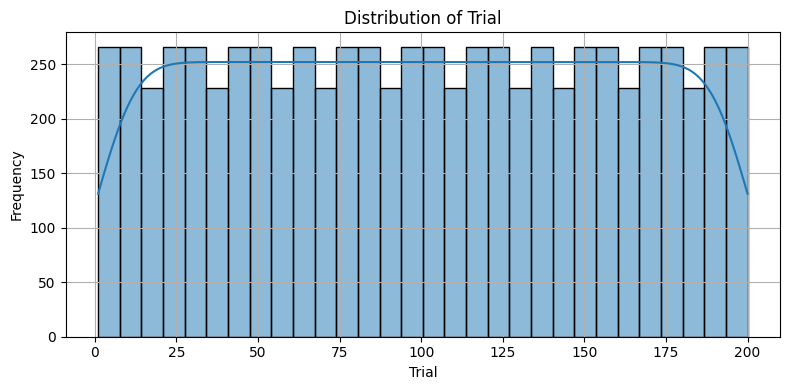

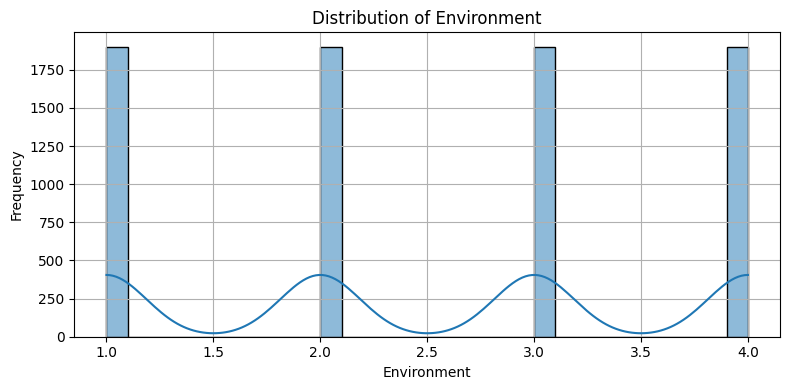

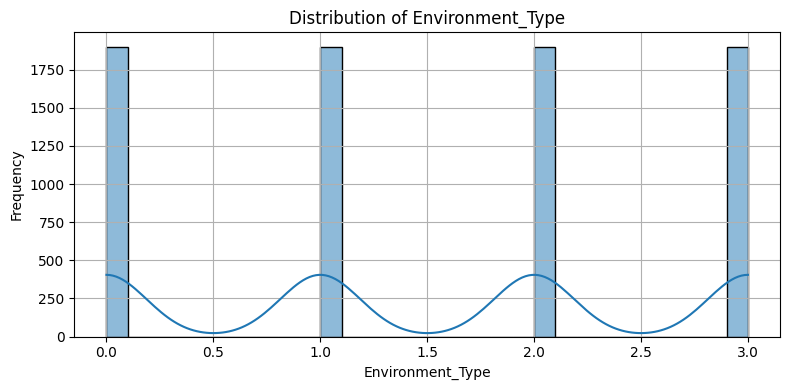

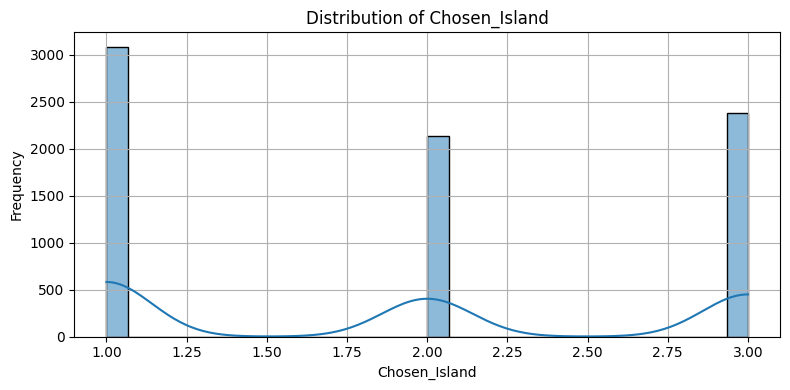

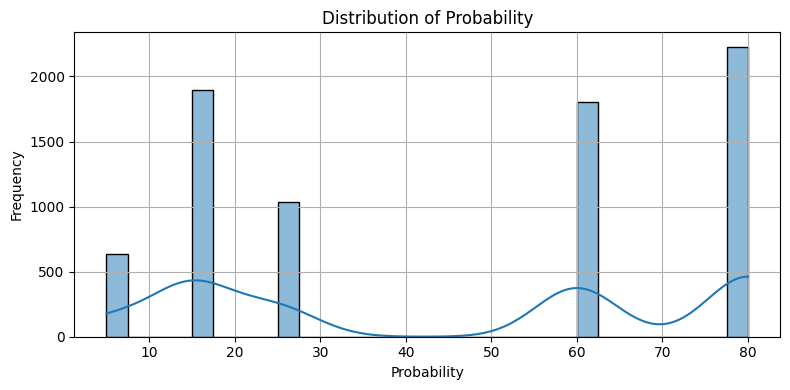

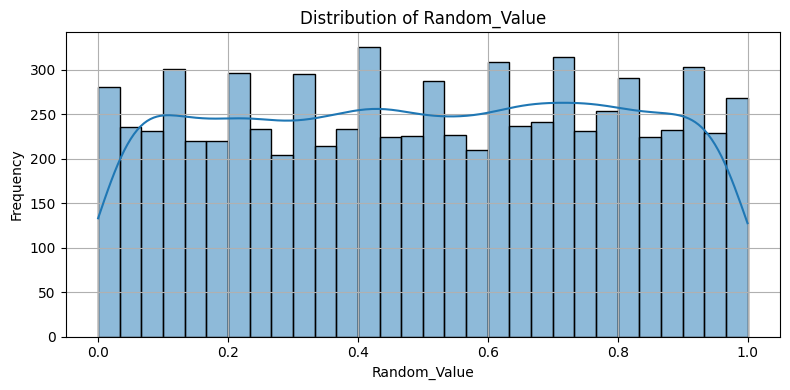

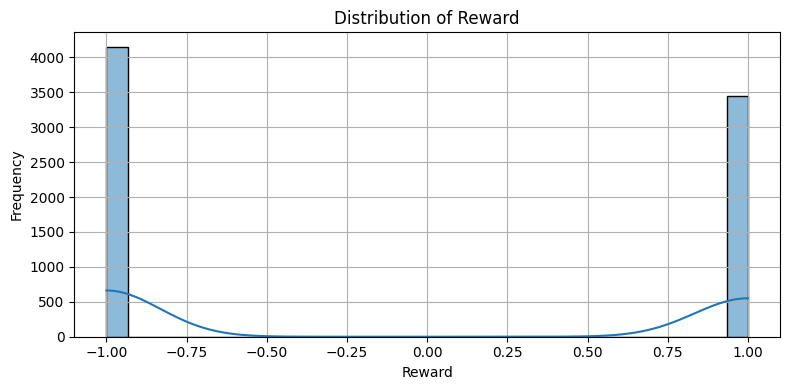

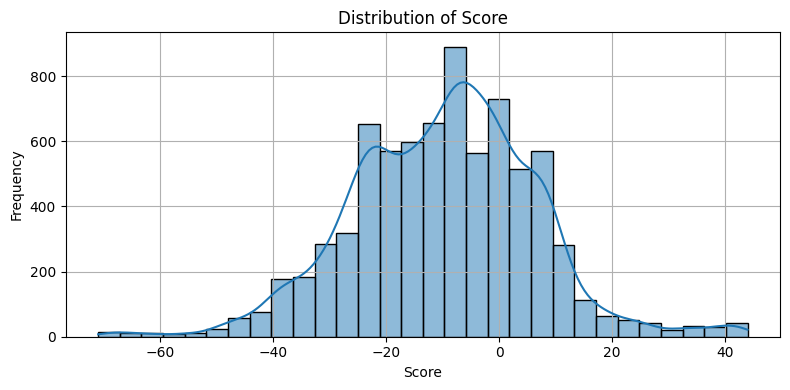

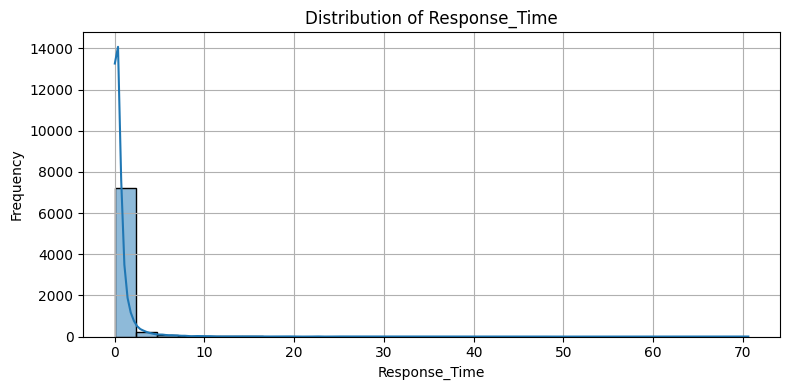

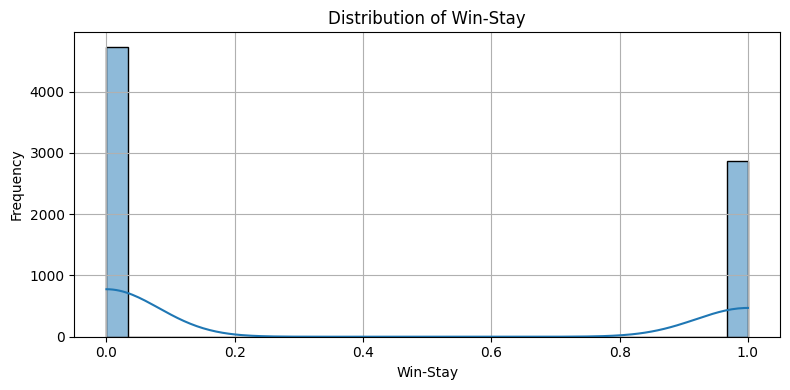

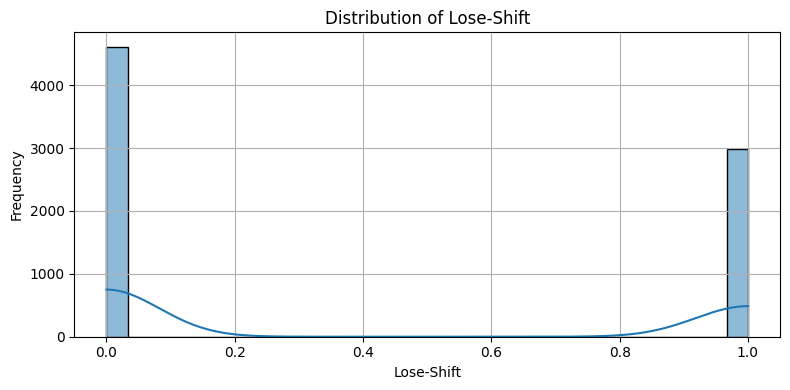

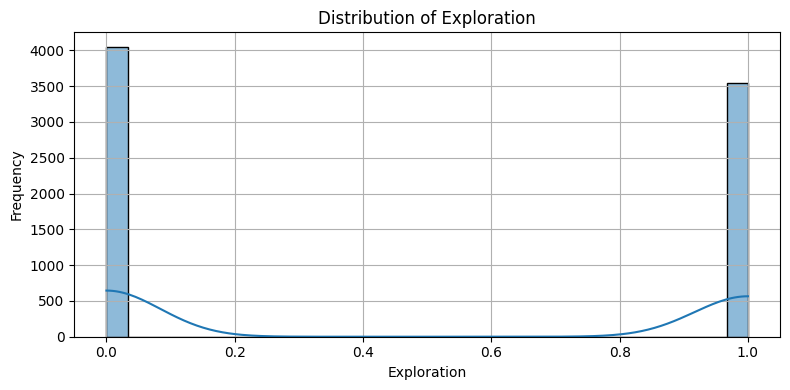

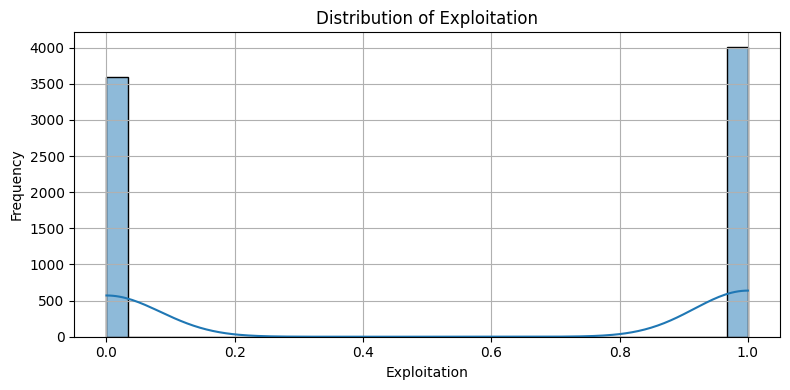

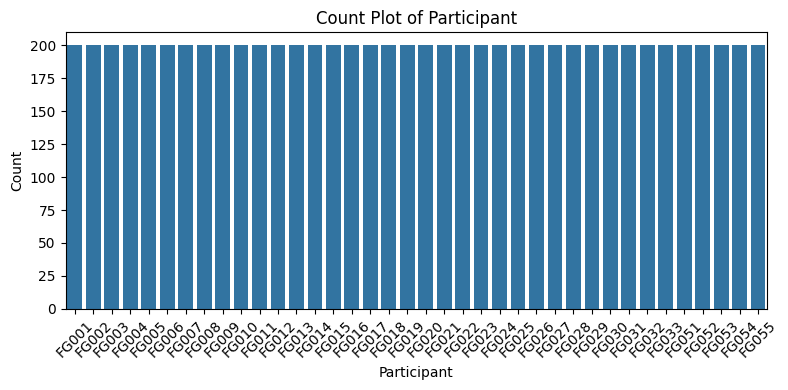

[INFO] Normalized features with MinMaxScaler.
     Environment  Environment_Type  Chosen_Island  Probability  Random_Value  \
0       0.000000          0.000000            0.0     0.733333          0.30   
127     0.666667          0.333333            0.5     0.733333          0.45   
128     0.666667          0.333333            1.0     0.266667          0.55   
129     0.666667          0.333333            0.0     0.133333          0.84   
130     0.666667          0.333333            1.0     0.266667          0.65   

     Reward     Score  Response_Time  Lose-Shift  Exploration  Exploitation  \
0       1.0  0.626087       0.080867         0.0          0.0           0.0   
127     1.0  0.269565       0.004815         1.0          1.0           0.0   
128     0.0  0.260870       0.002549         0.0          1.0           0.0   
129     0.0  0.252174       0.002266         1.0          1.0           0.0   
130     0.0  0.243478       0.014162         1.0          1.0           0.0   

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 200, 12)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 12)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 200, 64)        │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_encoding (Dense)         │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 200, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_decoder_1 (LSTM)           │ (None, 200, 128)       │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_decoder_2 (LSTM)           │ (None, 200, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 200, 12)        │           780 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 255,276 (997.17 KB)

 Trainable params: 255,276 (997.17 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 75ms/step - loss: 0.3612
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.2321
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.1849
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.1808
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.1764
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.1741
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.1719
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.1726
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.1720
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.1709
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.1700
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.1698
Epoch 13/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.1689
Epoch 14/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.1676
Epoch 15/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.1677
Epoch 16/100
3/3 ━

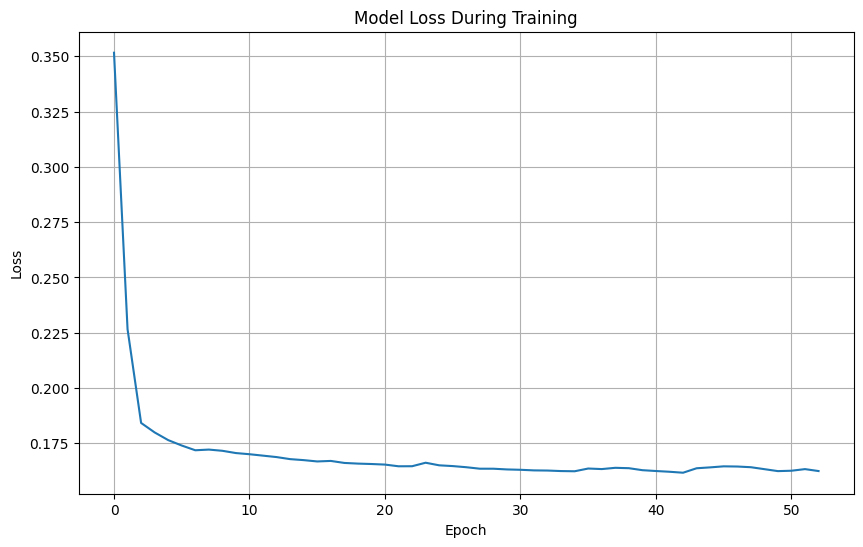

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
Generated embeddings with shape: (38, 32)
t-SNE reduction completed


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP reduction completed
Clustering completed for tsne
Clustering completed for umap


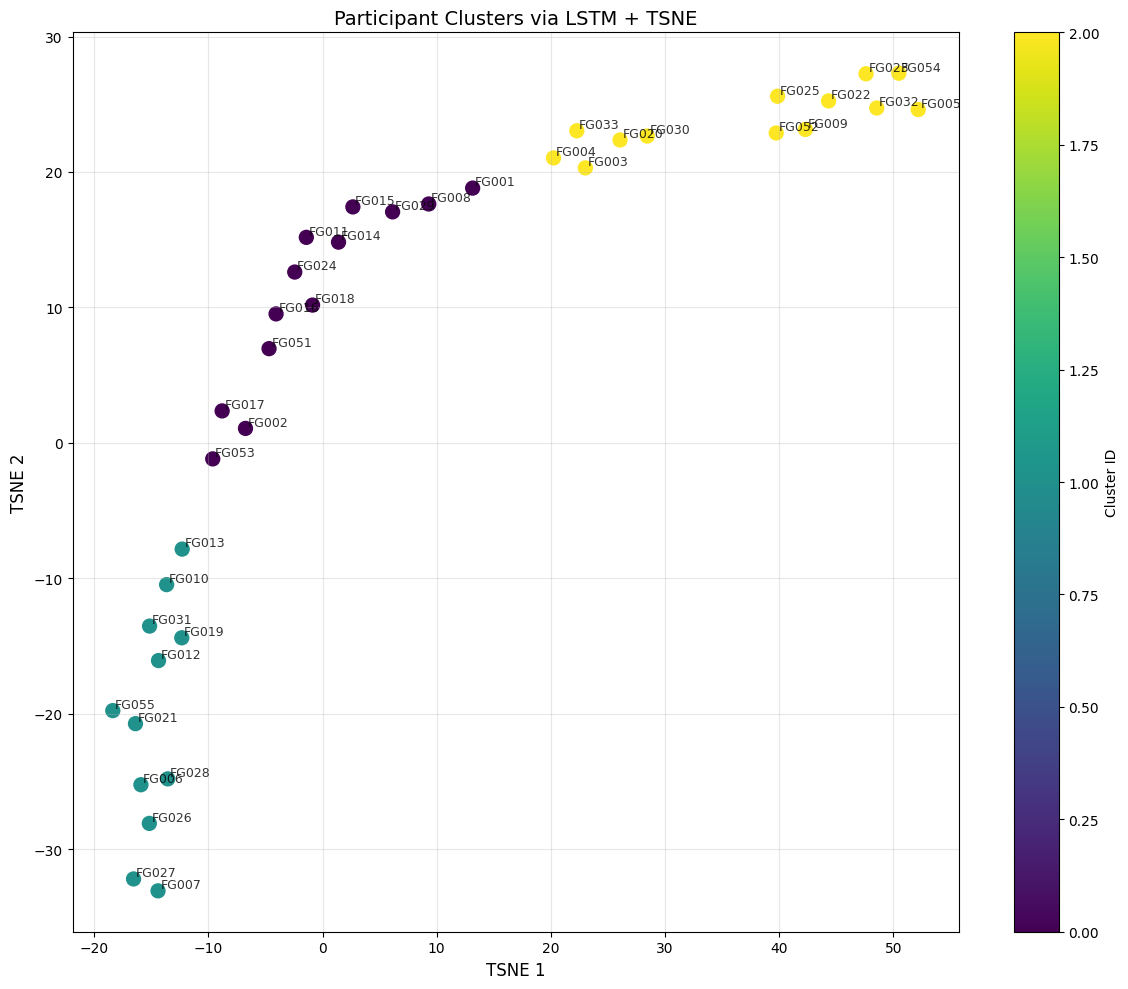

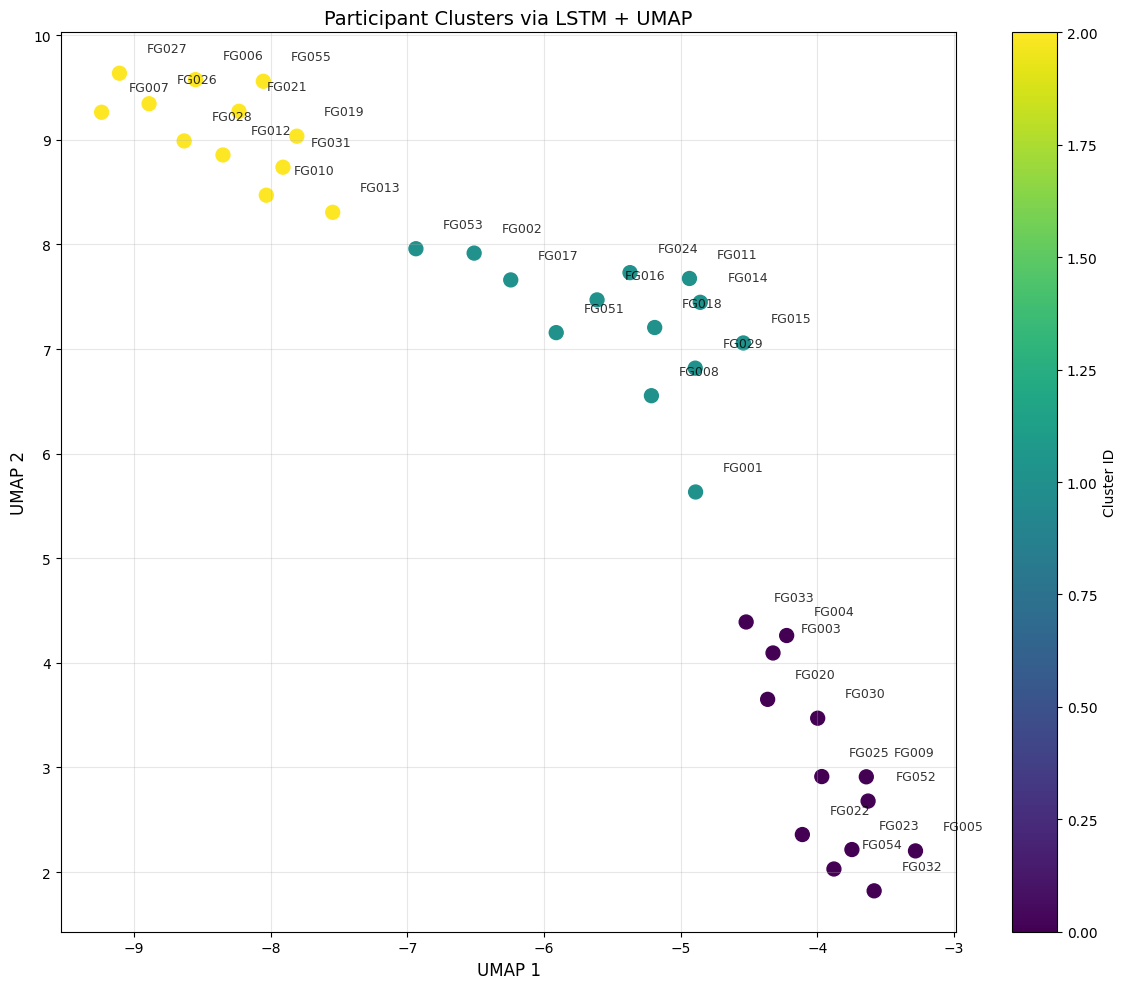


--- Participant Cluster Assignments ---
   Participant  Cluster Behavior_Type
0        FG001        0       group_1
1        FG002        0       group_1
2        FG003        2       group_3
3        FG004        2       group_3
4        FG005        2       group_3
5        FG006        1       group_2
6        FG007        1       group_2
7        FG008        0       group_1
8        FG009        2       group_3
9        FG010        1       group_2
10       FG011        0       group_1
11       FG012        1       group_2
12       FG013        1       group_2
13       FG014        0       group_1
14       FG015        0       group_1
15       FG016        0       group_1
16       FG017        0       group_1
17       FG018        0       group_1
18       FG019        1       group_2
19       FG020        2       group_3
20       FG021        1       group_2
21       FG022        2       group_3
22       FG023        2       group_3
23       FG024        0       group_1
24       

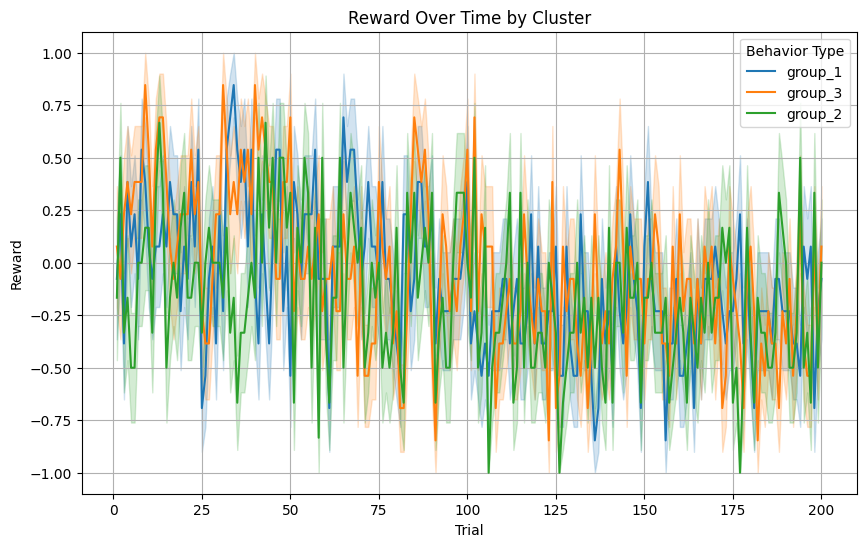

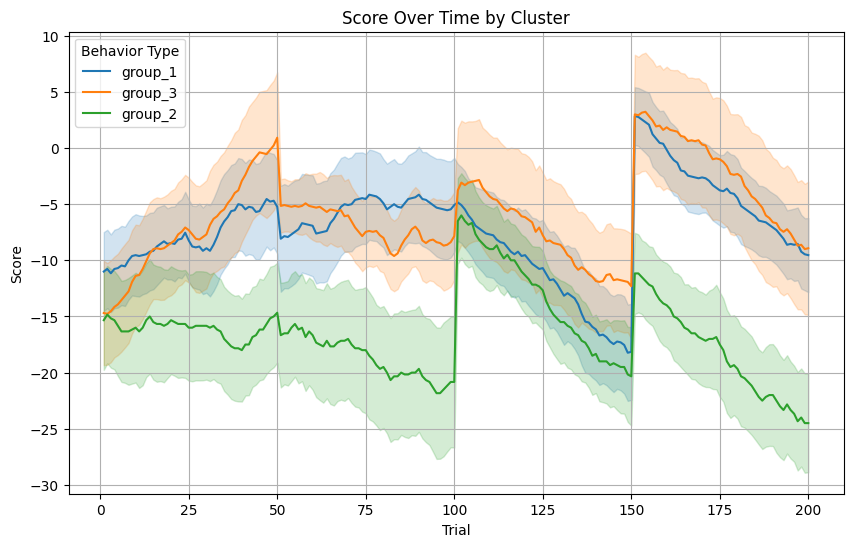

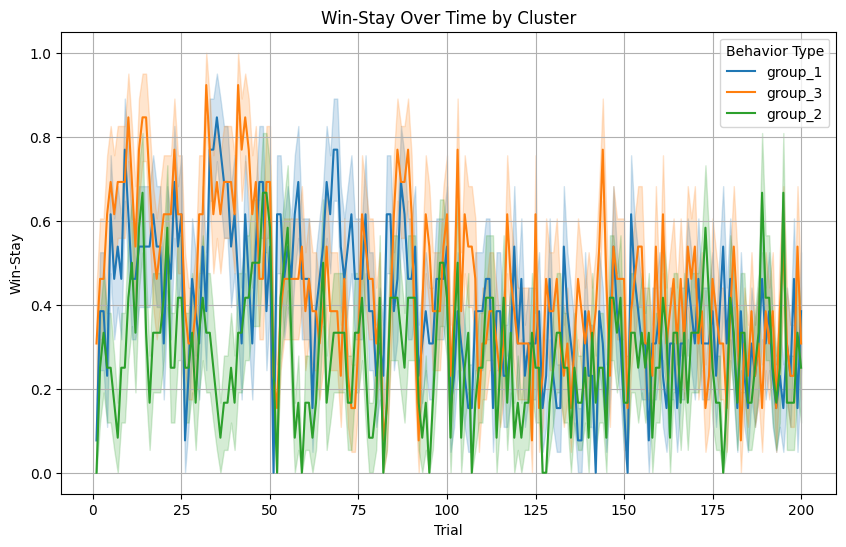

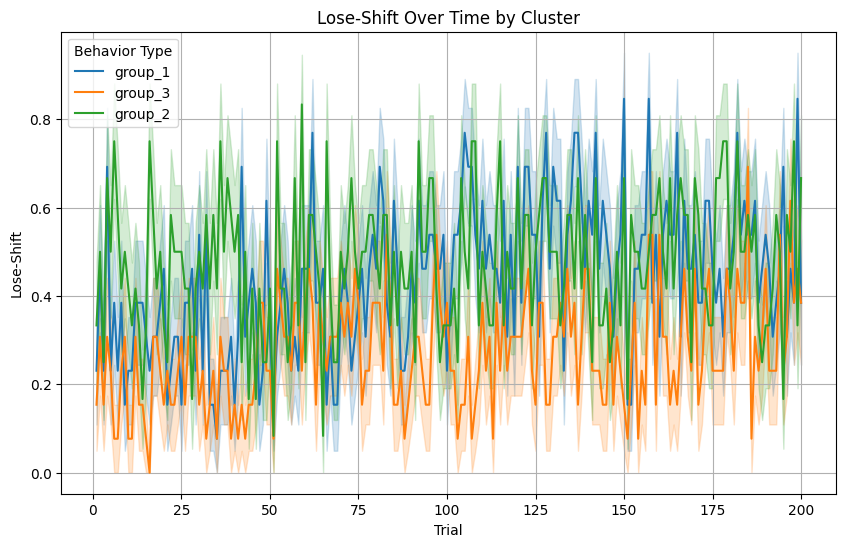

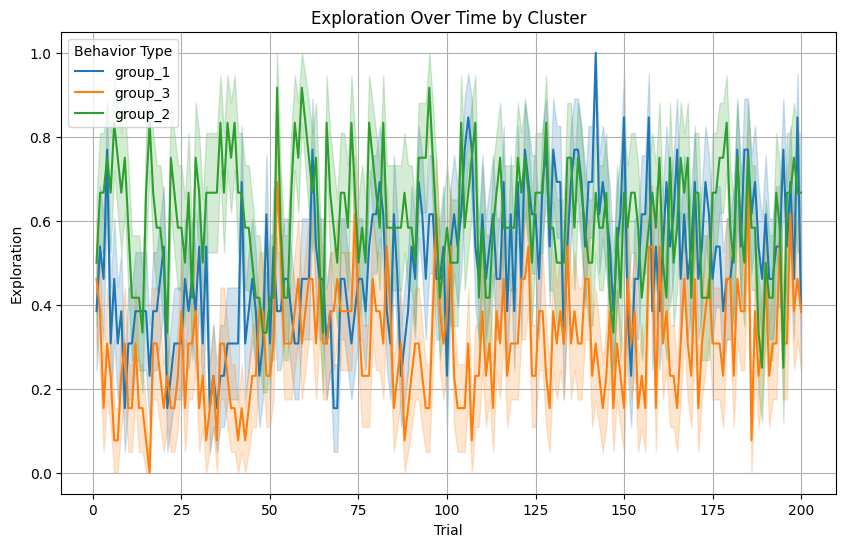

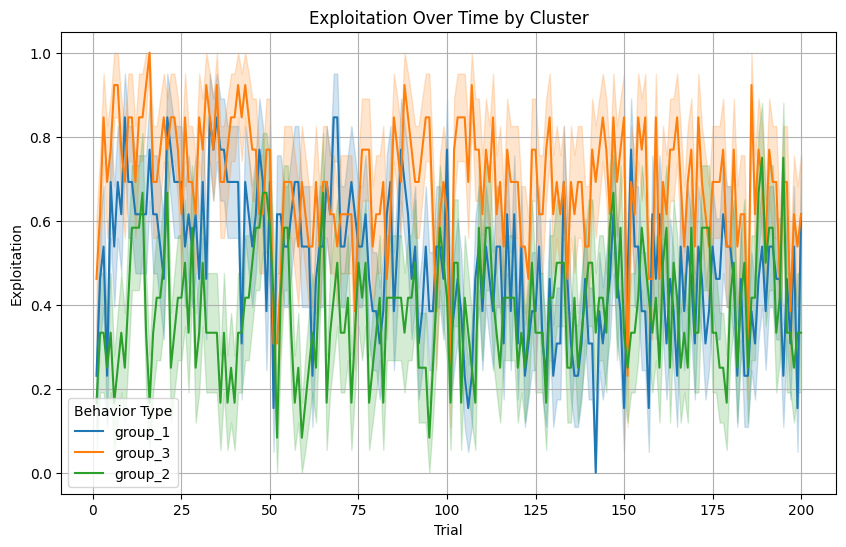

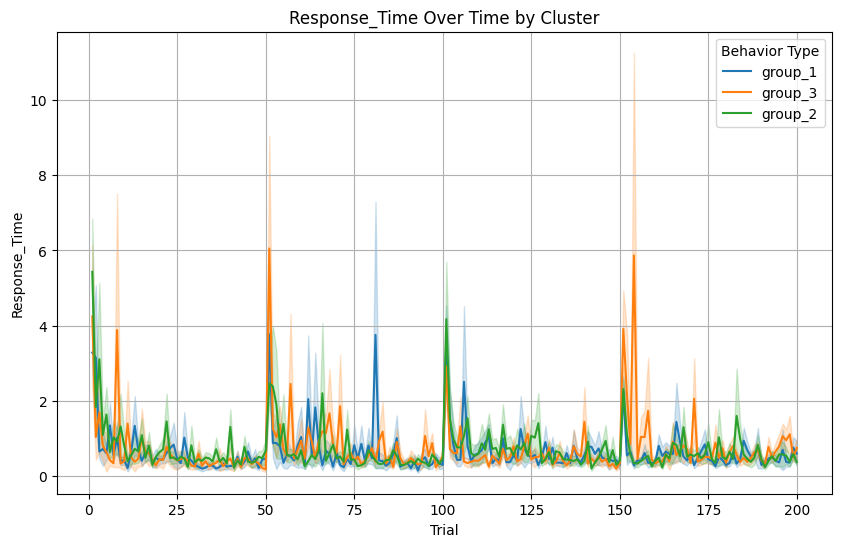


--- Analyzing Performance by Environment Type ---


--- Analysis for Score ---


Descriptive Statistics by Cluster and Environment:

                                count       mean        std   min    25%  \
Behavior_Type Environment_Name                                             
group_1       High-Fast         650.0  -3.764615  11.332554 -32.0 -10.00   
              High-Slow         650.0 -11.650769  14.758755 -47.0 -22.00   
              Low-Fast          650.0  -5.656923  14.818496 -45.0 -17.00   
              Low-Slow          650.0  -7.949231  13.334578 -37.0 -19.75   
group_2       High-Fast         600.0 -18.316667  14.472115 -49.0 -25.00   
              High-Slow         600.0 -13.446667  12.901857 -54.0 -17.00   
              Low-Fast          600.0 -18.690000  17.816086 -71.0 -25.00   
              Low-Slow          600.0 -16.063333  15.676913 -52.0 -27.00   
group_3       High-Fast         650.0  -2.112308  19.646522 -36.0 -16.00   
              High-Slow       

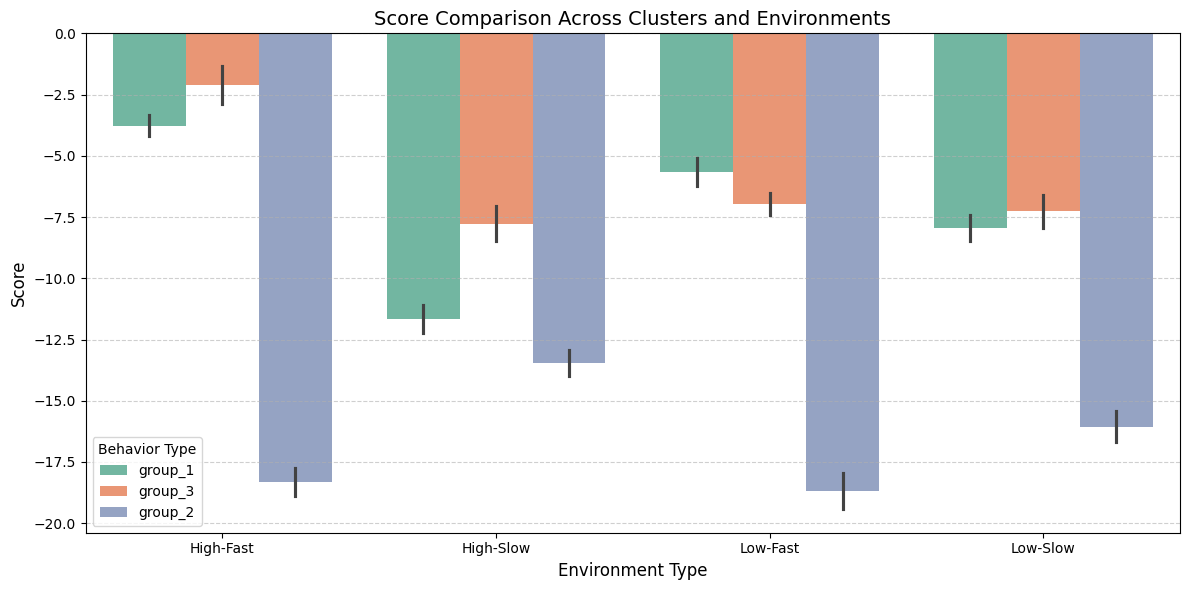

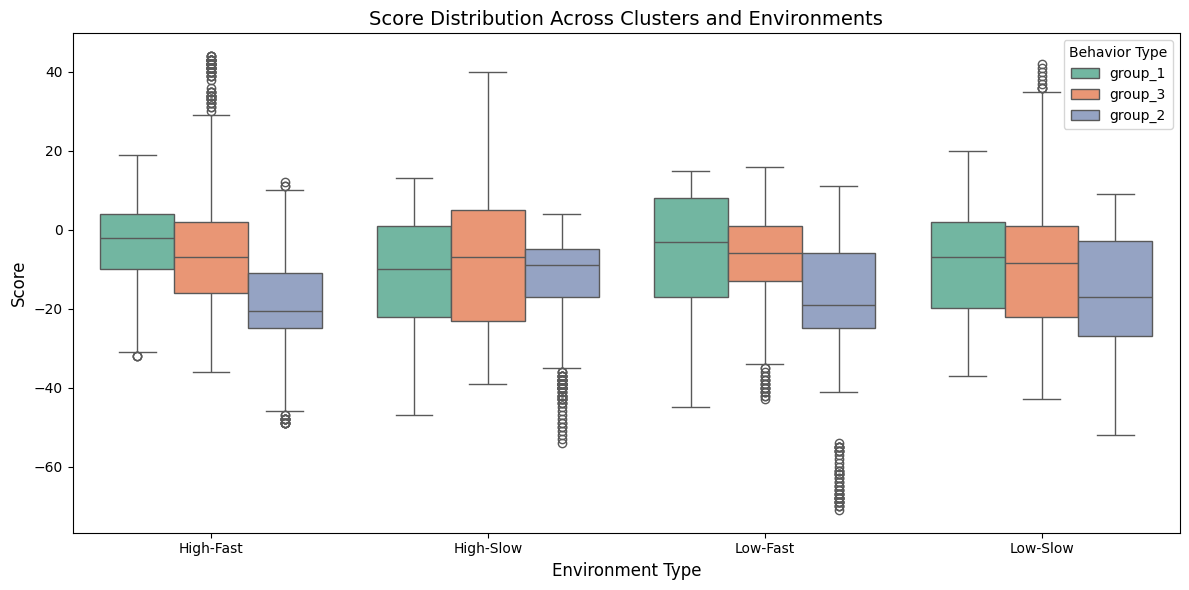


ANOVA Analysis Results:

                                            sum_sq      df           F  \
C(Behavior_Type)                      1.657036e+05     2.0  349.934610   
C(Environment_Type)                   1.067146e+04     3.0   15.024073   
C(Behavior_Type):C(Environment_Type)  3.582390e+04     6.0   25.217765   
Residual                              1.796563e+06  7588.0         NaN   

                                             PR(>F)  
C(Behavior_Type)                      4.273049e-146  
C(Environment_Type)                    9.519812e-10  
C(Behavior_Type):C(Environment_Type)   8.294183e-30  
Residual                                        NaN  


--- Analysis for Reward ---


Descriptive Statistics by Cluster and Environment:

                                count      mean       std  min  25%  50%  75%  \
Behavior_Type Environment_Name                                                  
group_1       High-Fast         650.0 -0.240000  0.971520 -1.0 -1.0 -1.0  1.0   
      

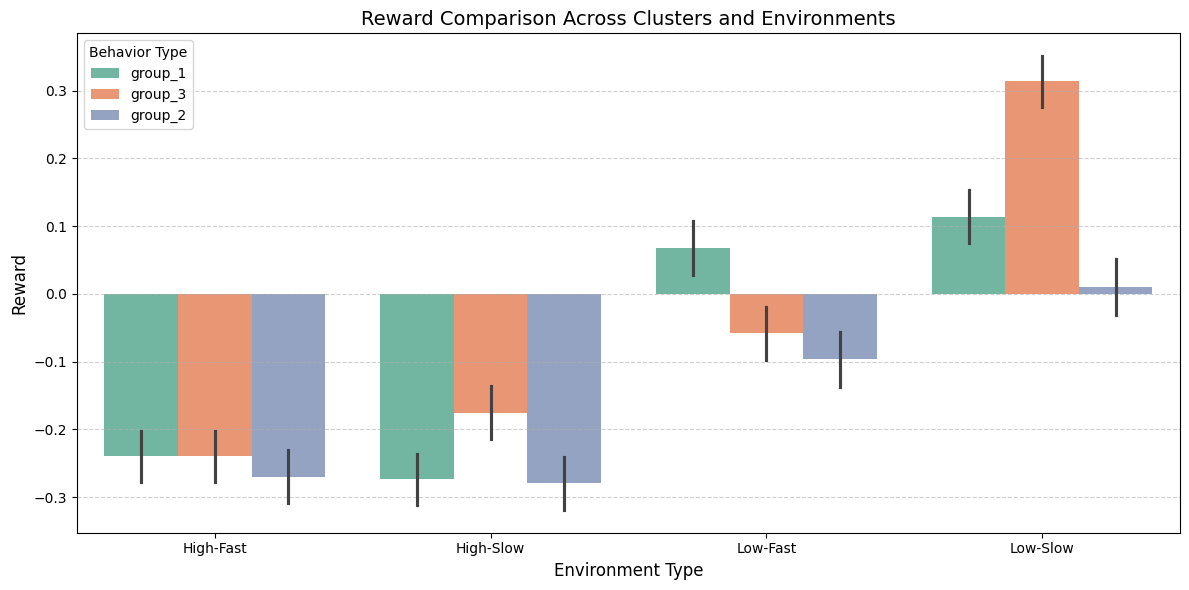

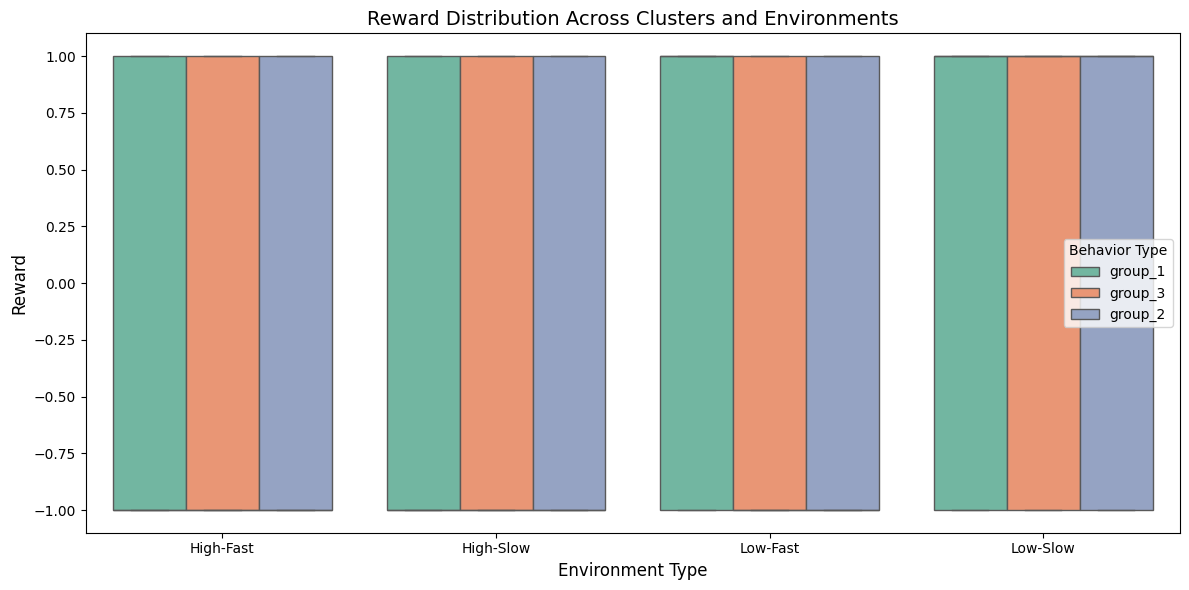


ANOVA Analysis Results:

                                           sum_sq      df          F  \
C(Behavior_Type)                        18.063650     2.0   9.410986   
C(Environment_Type)                    208.650000     3.0  72.469747   
C(Behavior_Type):C(Environment_Type)    26.158077     6.0   4.542701   
Residual                              7282.285641  7588.0        NaN   

                                            PR(>F)  
C(Behavior_Type)                      8.277921e-05  
C(Environment_Type)                   3.313816e-46  
C(Behavior_Type):C(Environment_Type)  1.320008e-04  
Residual                                       NaN  


--- Analysis for Response_Time ---


Descriptive Statistics by Cluster and Environment:

                                count      mean       std   min     25%   50%  \
Behavior_Type Environment_Name                                                  
group_1       High-Fast         650.0  0.559231  0.995105  0.01  0.1225  0.26   
              

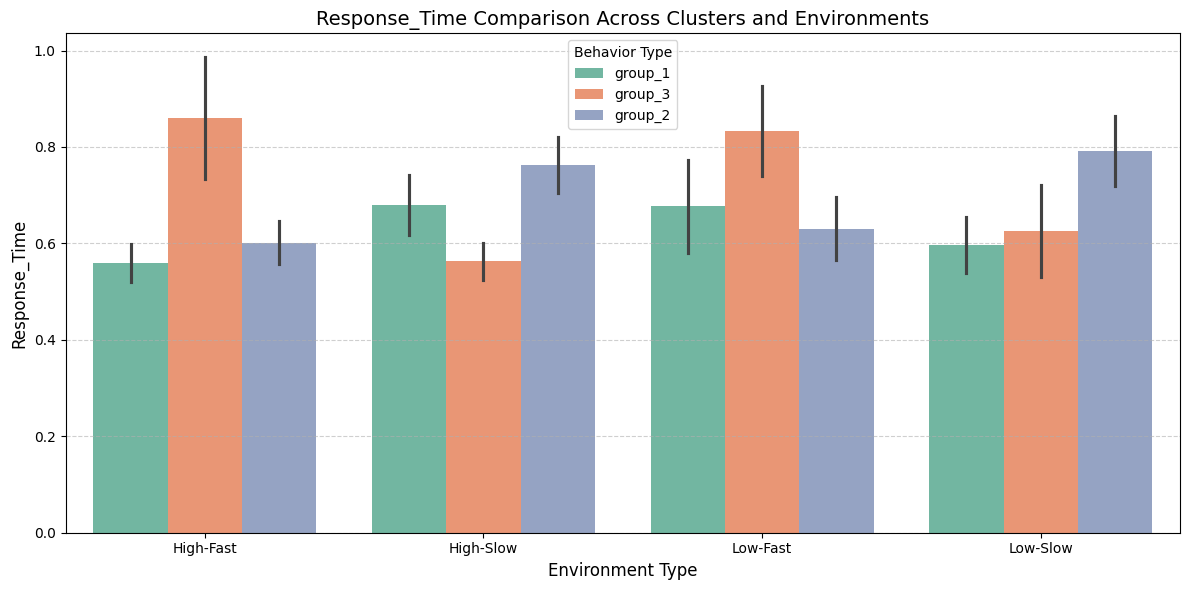

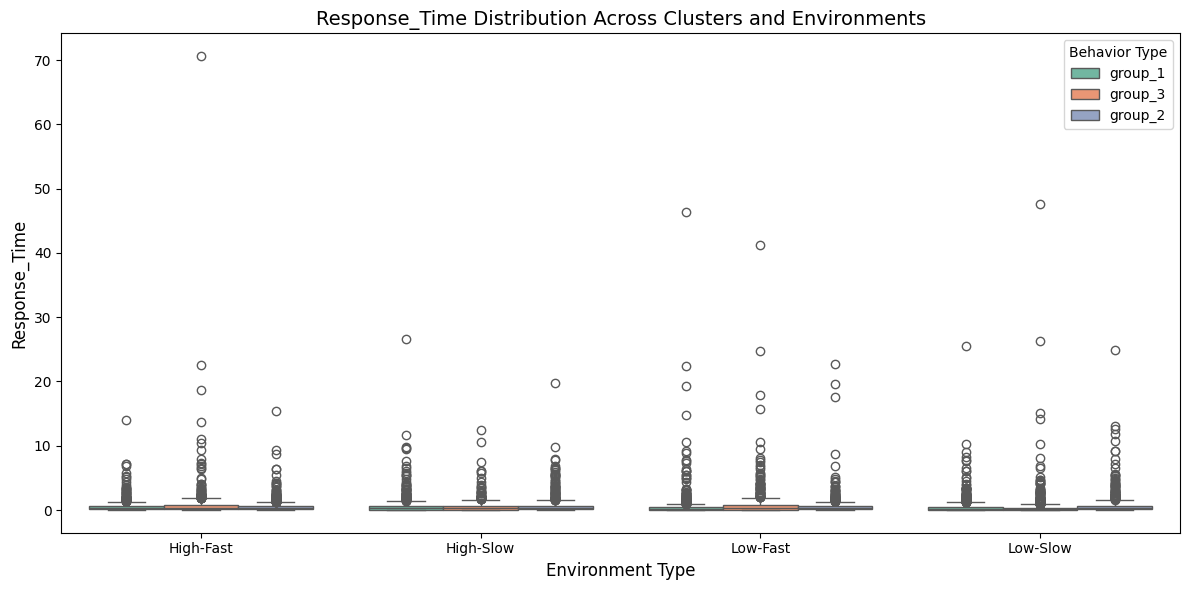


ANOVA Analysis Results:

                                            sum_sq      df         F    PR(>F)
C(Behavior_Type)                         11.912983     2.0  1.619445  0.198077
C(Environment_Type)                       3.115879     3.0  0.282381  0.838159
C(Behavior_Type):C(Environment_Type)     62.976344     6.0  2.853657  0.008897
Residual                              27909.479968  7588.0       NaN       NaN


--- Analysis for Win-Stay ---


Descriptive Statistics by Cluster and Environment:

                                count      mean       std  min  25%  50%  75%  \
Behavior_Type Environment_Name                                                  
group_1       High-Fast         650.0  0.306154  0.461249  0.0  0.0  0.0  1.0   
              High-Slow         650.0  0.292308  0.455173  0.0  0.0  0.0  1.0   
              Low-Fast          650.0  0.475385  0.499778  0.0  0.0  0.0  1.0   
              Low-Slow          650.0  0.510769  0.500269  0.0  0.0  1.0  1.0   
group_2

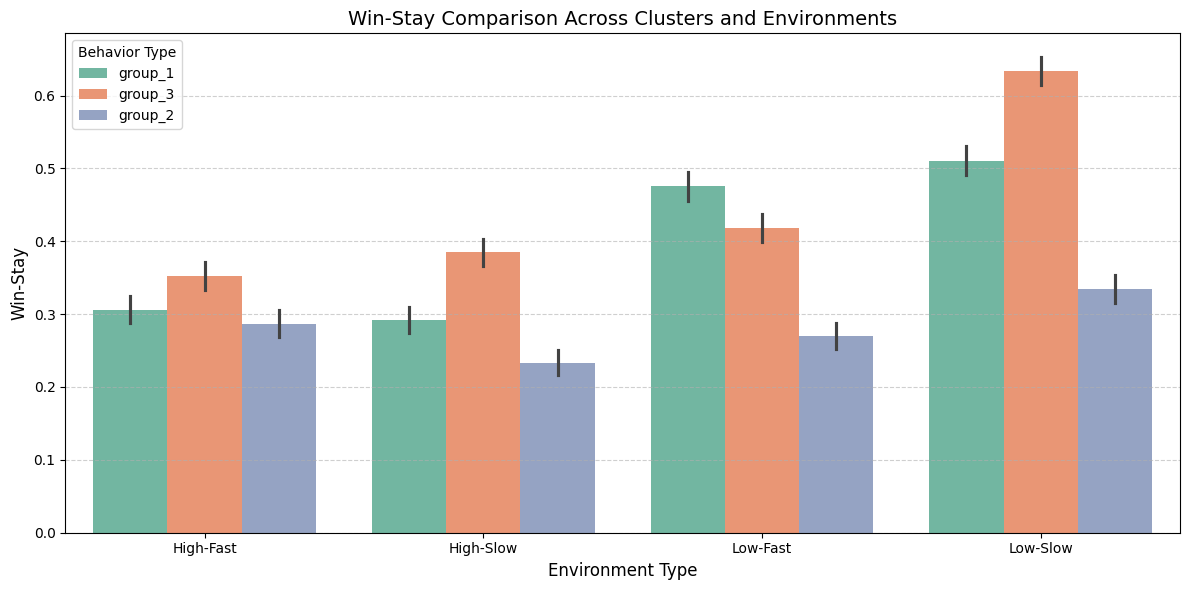

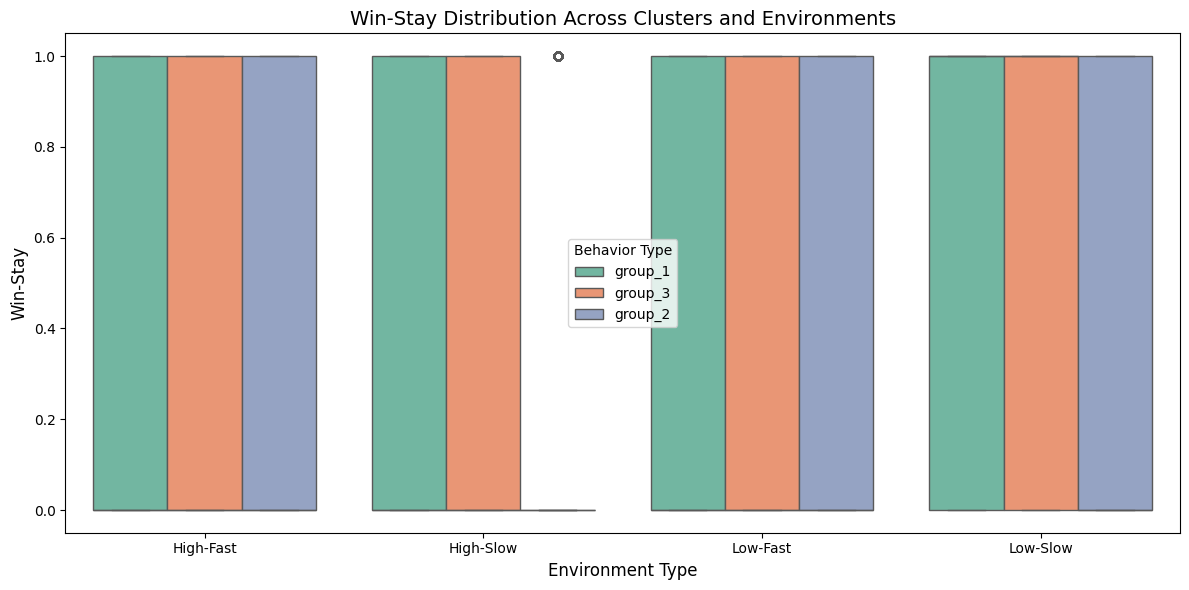

Error in ANOVA analysis for Win-Stay: error tokenizing input (maybe an unclosed string?)
    `Win-Stay` ~ C(Behavior_Type) * C(Environment_Type)
    ^


--- Analysis for Exploration ---


Descriptive Statistics by Cluster and Environment:

                                count      mean       std  min  25%  50%  75%  \
Behavior_Type Environment_Name                                                  
group_1       High-Fast         650.0  0.560000  0.496769  0.0  0.0  1.0  1.0   
              High-Slow         650.0  0.618462  0.486138  0.0  0.0  1.0  1.0   
              Low-Fast          650.0  0.452308  0.498104  0.0  0.0  0.0  1.0   
              Low-Slow          650.0  0.364615  0.481693  0.0  0.0  0.0  1.0   
group_2       High-Fast         600.0  0.585000  0.493133  0.0  0.0  1.0  1.0   
              High-Slow         600.0  0.603333  0.489614  0.0  0.0  1.0  1.0   
              Low-Fast          600.0  0.645000  0.478913  0.0  0.0  1.0  1.0   
              Low-Slow         

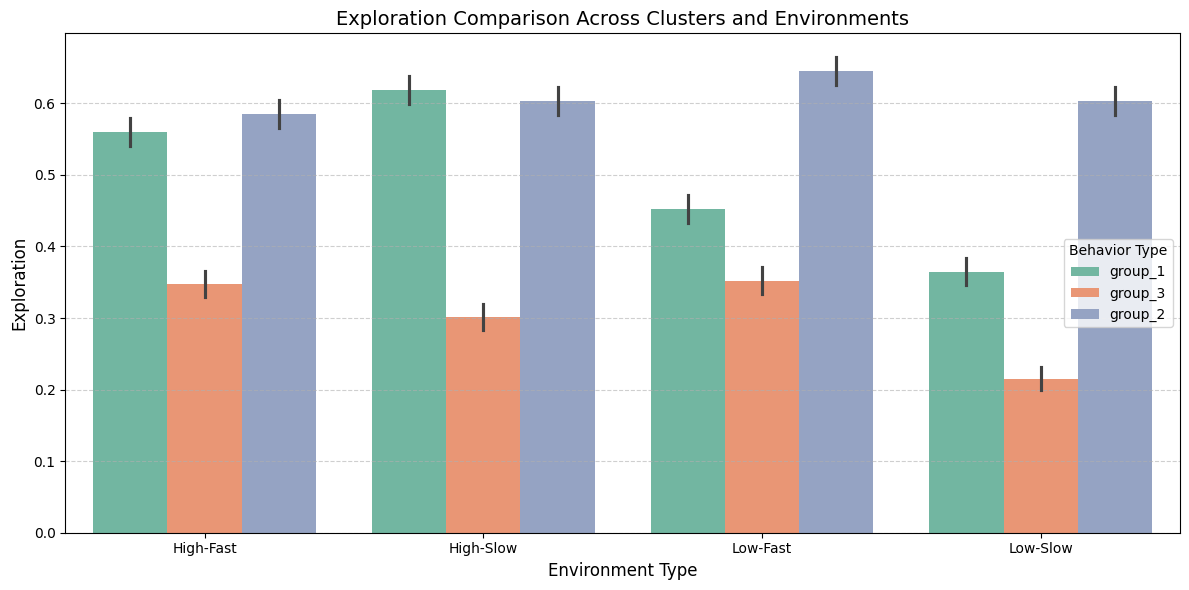

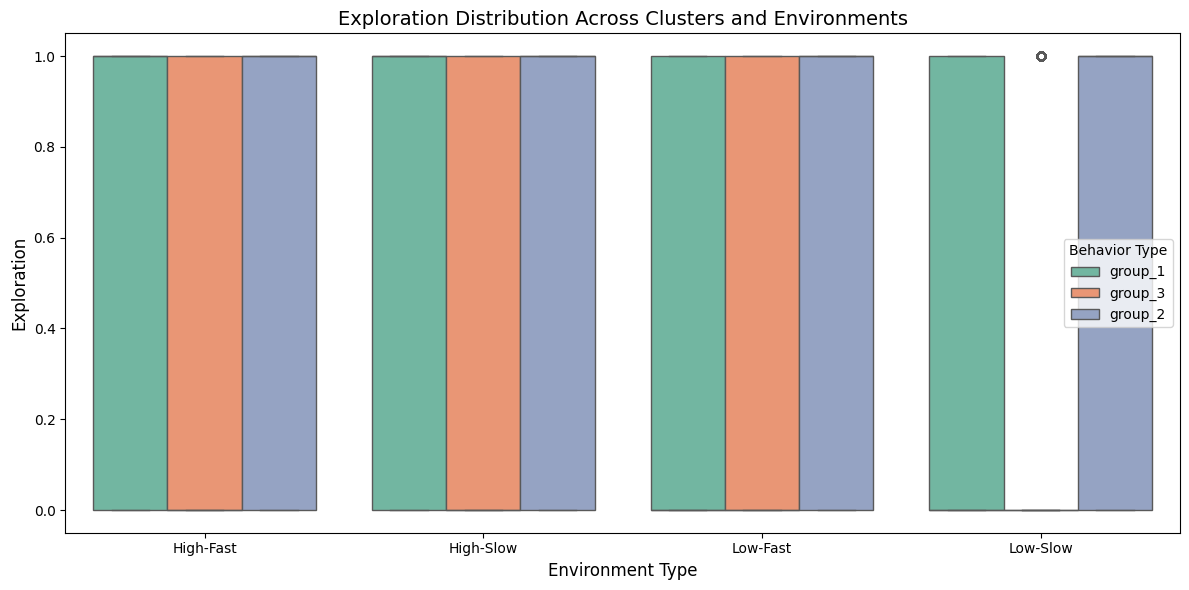


ANOVA Analysis Results:

                                           sum_sq      df           F  \
C(Behavior_Type)                       120.027982     2.0  262.036879   
C(Environment_Type)                     16.145789     3.0   23.498922   
C(Behavior_Type):C(Environment_Type)    17.732031     6.0   12.903786   
Residual                              1737.870513  7588.0         NaN   

                                             PR(>F)  
C(Behavior_Type)                      9.050381e-111  
C(Environment_Type)                    3.913700e-15  
C(Behavior_Type):C(Environment_Type)   1.450963e-14  
Residual                                        NaN  


--- Analysis for Exploitation ---


Descriptive Statistics by Cluster and Environment:

                                count      mean       std  min  25%  50%  75%  \
Behavior_Type Environment_Name                                                  
group_1       High-Fast         650.0  0.436923  0.496387  0.0  0.0  0.0  1.0   
     

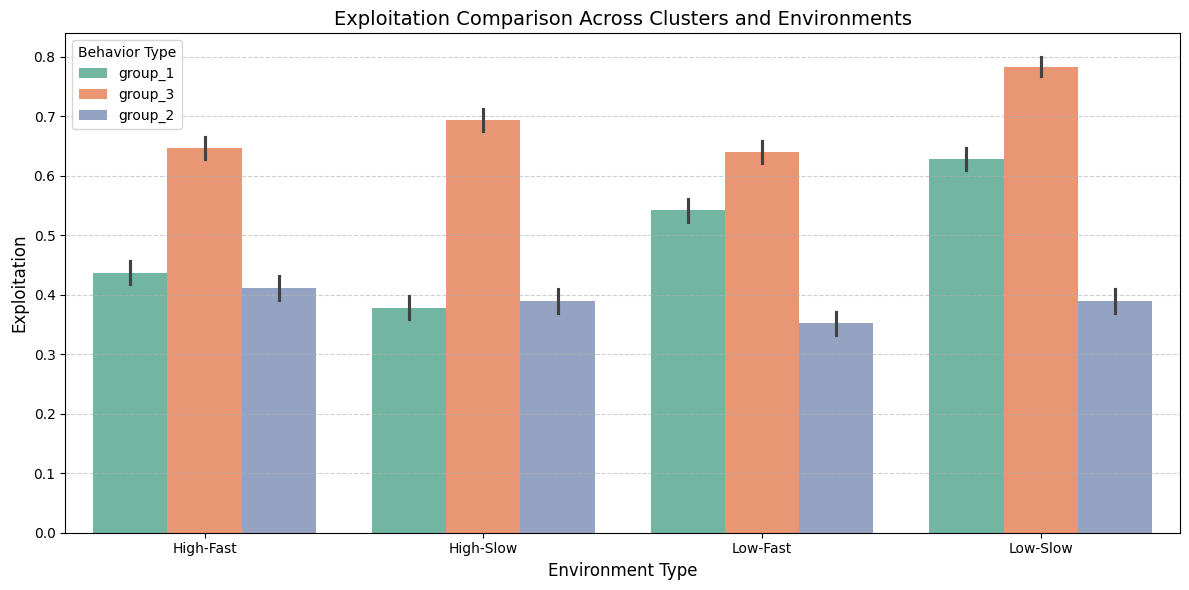

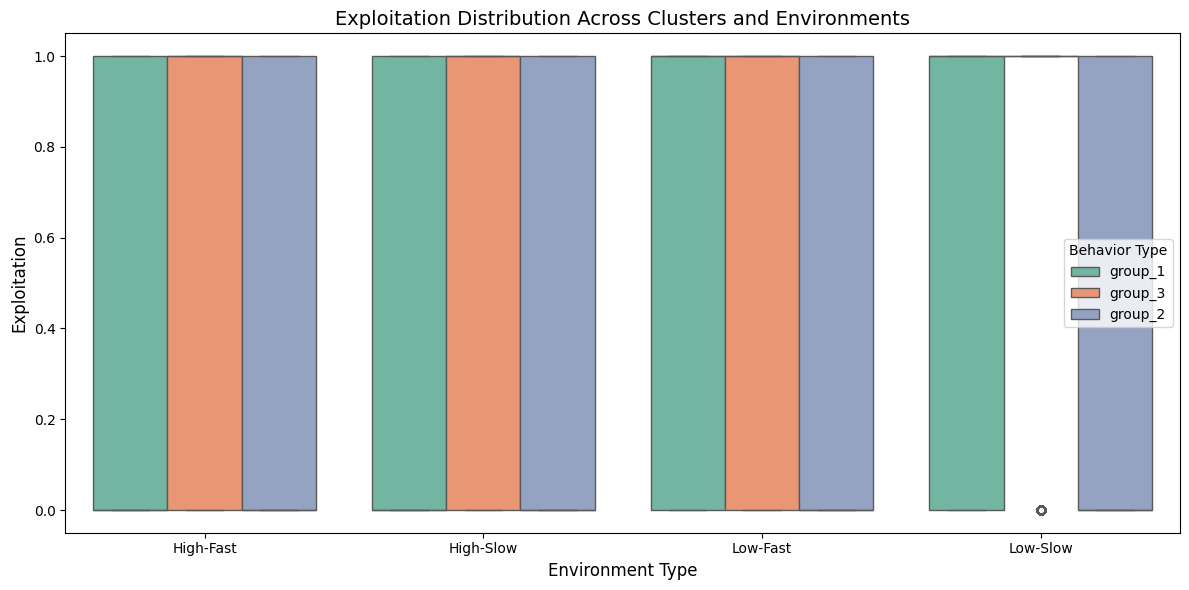


ANOVA Analysis Results:

                                           sum_sq      df           F  \
C(Behavior_Type)                       120.027982     2.0  261.632947   
C(Environment_Type)                     15.983158     3.0   23.226366   
C(Behavior_Type):C(Environment_Type)    17.521586     6.0   12.730987   
Residual                              1740.553590  7588.0         NaN   

                                             PR(>F)  
C(Behavior_Type)                      1.320588e-110  
C(Environment_Type)                    5.835477e-15  
C(Behavior_Type):C(Environment_Type)   2.361812e-14  
Residual                                        NaN  

--- Analyzing Performance by Volatility Level ---


--- Volatility Analysis for Score ---


Descriptive Statistics by Cluster and Volatility Level:

                                 count       mean        std   min   25%  \
Behavior_Type Volatility_Level                                             
group_1       High Volatility   1300

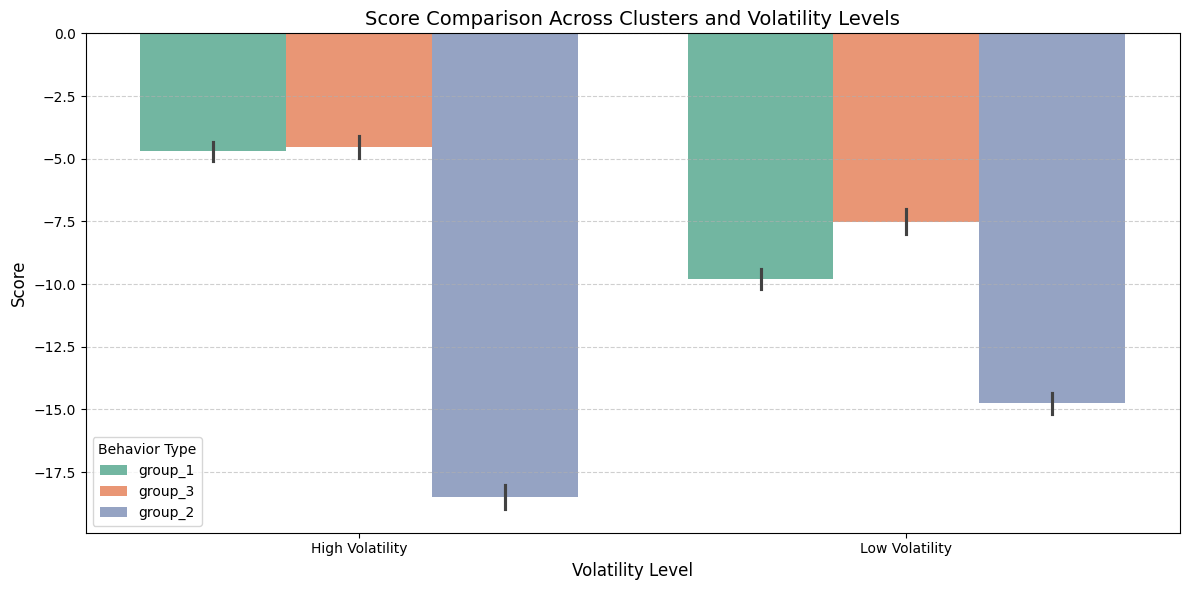

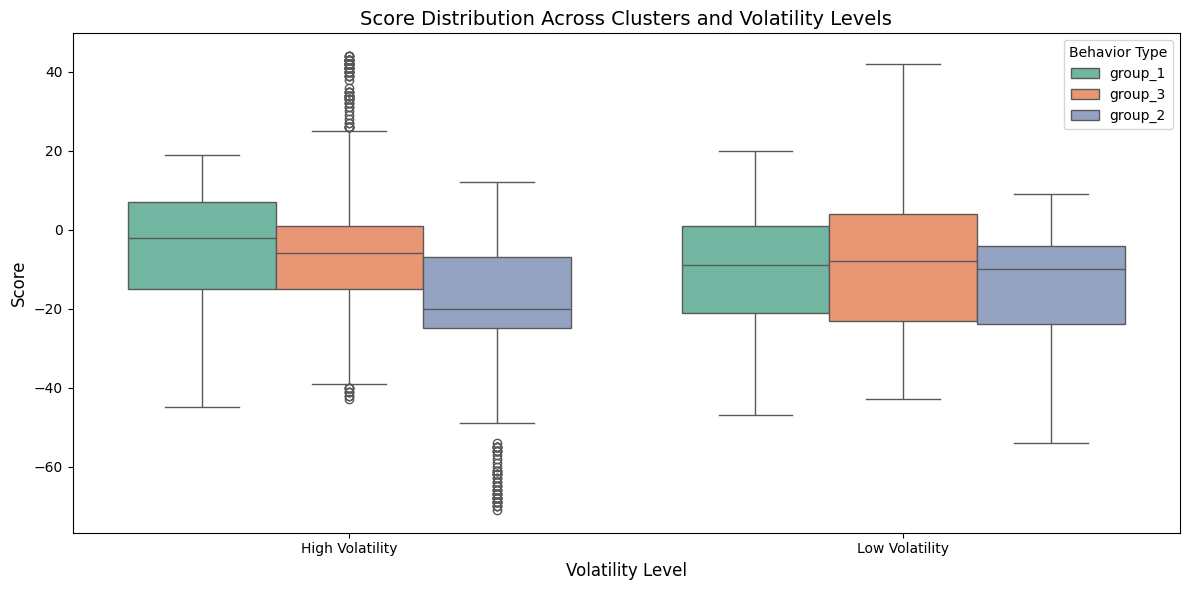


ANOVA Analysis Results for Volatility Effect:

                                              sum_sq      df           F  \
C(Behavior_Type)                        1.657036e+05     2.0  347.222598   
C(Volatility_Numeric)                   4.721066e+03     1.0   19.785458   
C(Behavior_Type):C(Volatility_Numeric)  2.631041e+04     2.0   55.131998   
Residual                                1.812026e+06  7594.0         NaN   

                                               PR(>F)  
C(Behavior_Type)                        5.065159e-145  
C(Volatility_Numeric)                    8.787335e-06  
C(Behavior_Type):C(Volatility_Numeric)   1.692941e-24  
Residual                                          NaN  

Difference in Performance Between Volatility Levels:

Volatility_Level  High Volatility  Low Volatility  Difference  Percent_Change
Behavior_Type                                                                
group_1                 -4.710769          -9.800    5.089231      -51.930926
gr

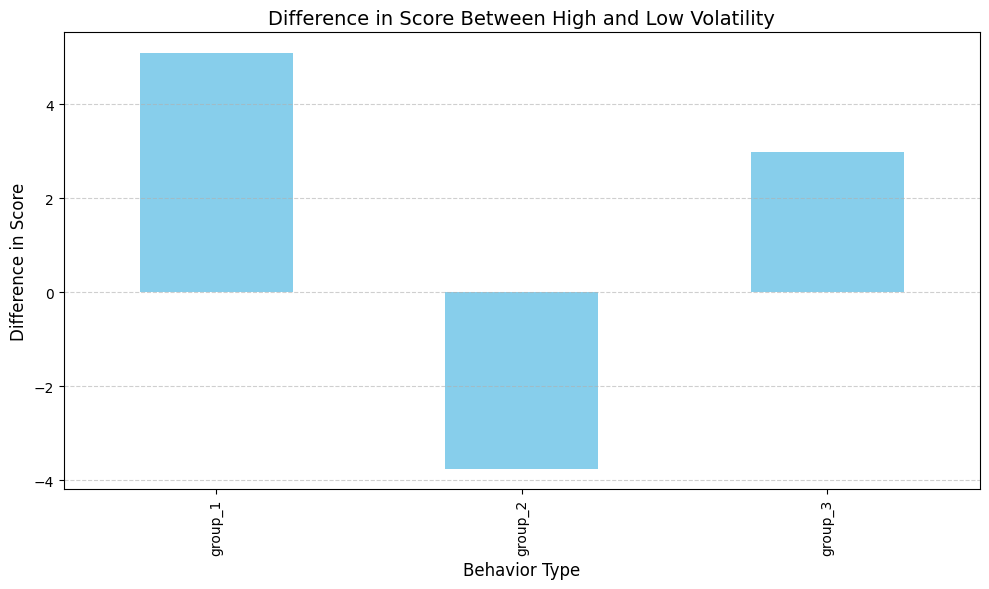



--- Volatility Analysis for Reward ---


Descriptive Statistics by Cluster and Volatility Level:

                                 count      mean       std  min  25%  50%  \
Behavior_Type Volatility_Level                                              
group_1       High Volatility   1300.0 -0.086154  0.996665 -1.0 -1.0 -1.0   
              Low Volatility    1300.0 -0.080000  0.997178 -1.0 -1.0 -1.0   
group_2       High Volatility   1200.0 -0.183333  0.983461 -1.0 -1.0 -1.0   
              Low Volatility    1200.0 -0.135000  0.991259 -1.0 -1.0 -1.0   
group_3       High Volatility   1300.0 -0.149231  0.989183 -1.0 -1.0 -1.0   
              Low Volatility    1300.0  0.069231  0.997985 -1.0 -1.0  1.0   

                                75%  max  
Behavior_Type Volatility_Level            
group_1       High Volatility   1.0  1.0  
              Low Volatility    1.0  1.0  
group_2       High Volatility   1.0  1.0  
              Low Volatility    1.0  1.0  
group_3       High Volati

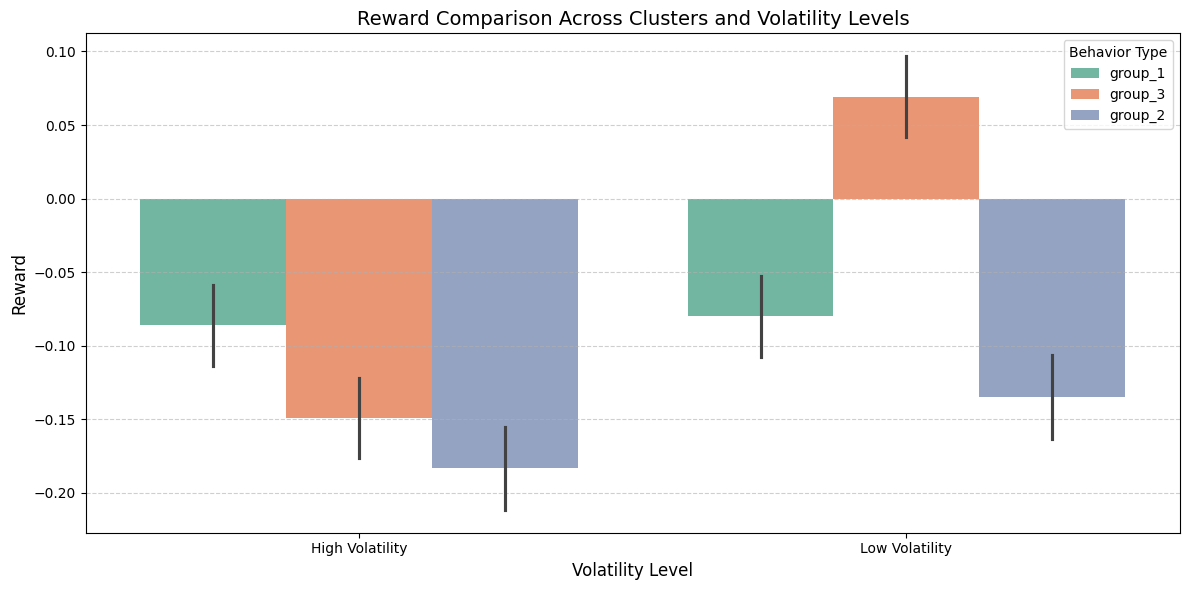

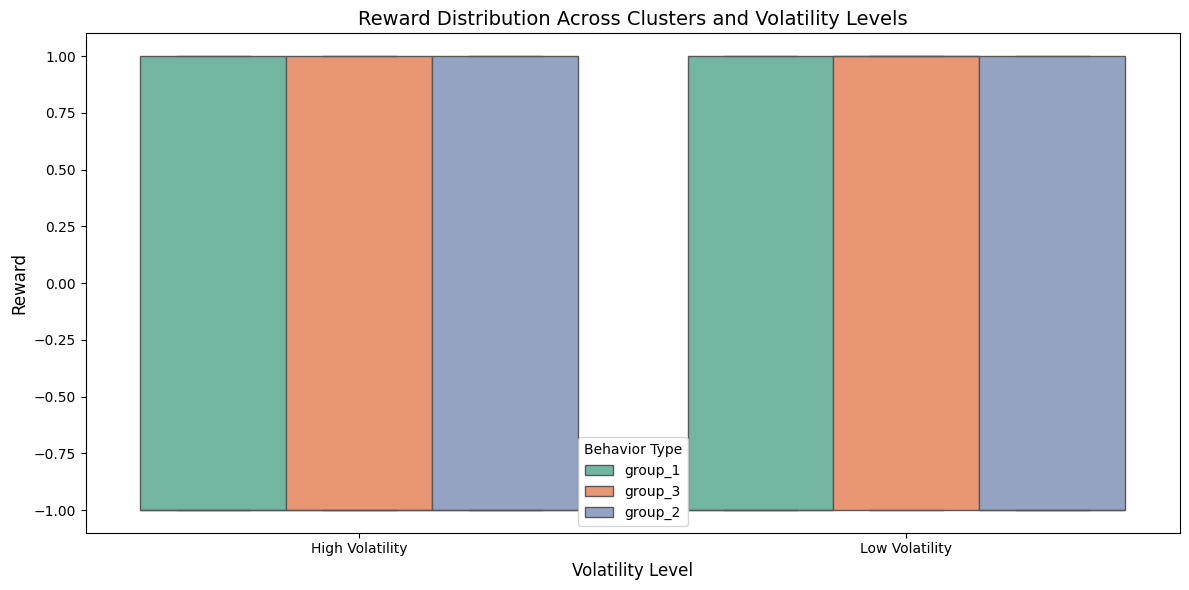


ANOVA Analysis Results for Volatility Effect:

                                             sum_sq      df          F  \
C(Behavior_Type)                          18.063650     2.0   9.163784   
C(Volatility_Numeric)                     16.118421     1.0  16.353919   
C(Behavior_Type):C(Volatility_Numeric)    16.329399     2.0   8.283990   
Residual                                7484.645897  7594.0        NaN   

                                          PR(>F)  
C(Behavior_Type)                        0.000106  
C(Volatility_Numeric)                   0.000053  
C(Behavior_Type):C(Volatility_Numeric)  0.000255  
Residual                                     NaN  

Difference in Performance Between Volatility Levels:

Volatility_Level  High Volatility  Low Volatility  Difference  Percent_Change
Behavior_Type                                                                
group_1                 -0.086154       -0.080000   -0.006154        7.692308
group_2                 -0.183333    

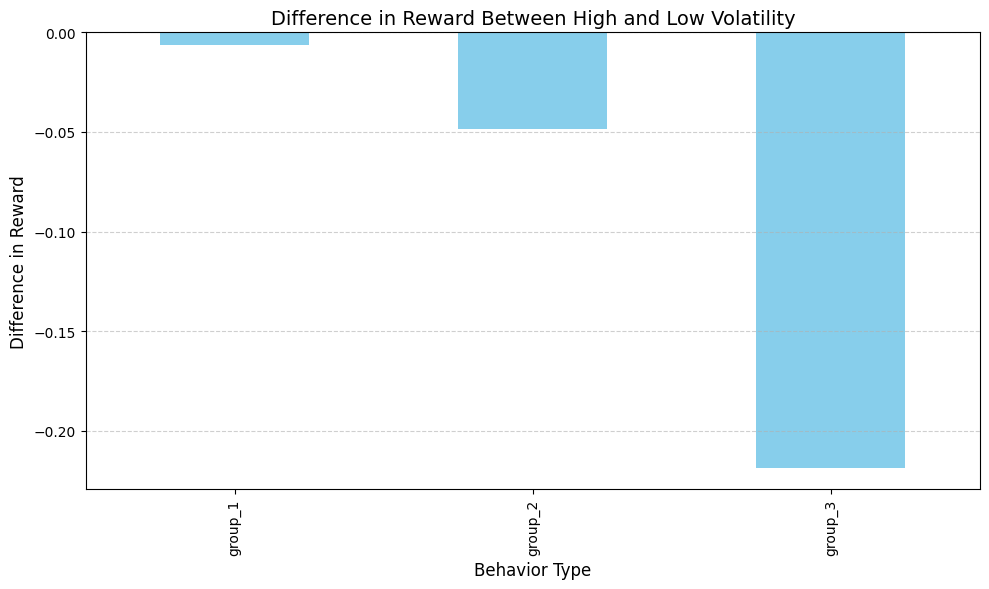



--- Volatility Analysis for Response_Time ---


Descriptive Statistics by Cluster and Volatility Level:

                                 count      mean       std   min   25%    50%  \
Behavior_Type Volatility_Level                                                  
group_1       High Volatility   1300.0  0.617992  1.884319  0.01  0.09  0.230   
              Low Volatility    1300.0  0.637992  1.525276  0.01  0.09  0.230   
group_2       High Volatility   1200.0  0.616142  1.377674  0.01  0.12  0.280   
              Low Volatility    1200.0  0.777025  1.612979  0.01  0.13  0.315   
group_3       High Volatility   1300.0  0.846862  2.827539  0.01  0.08  0.300   
              Low Volatility    1300.0  0.593831  1.861894  0.01  0.07  0.210   

                                   75%    max  
Behavior_Type Volatility_Level                 
group_1       High Volatility   0.5100  46.32  
              Low Volatility    0.5850  26.58  
group_2       High Volatility   0.6000  22.68  
    

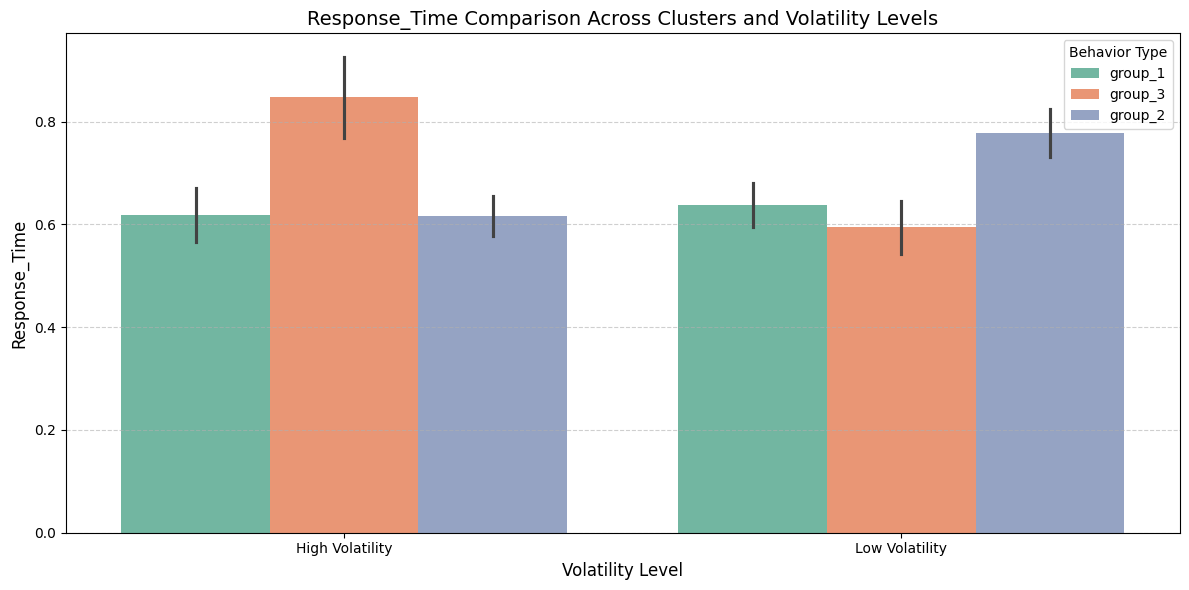

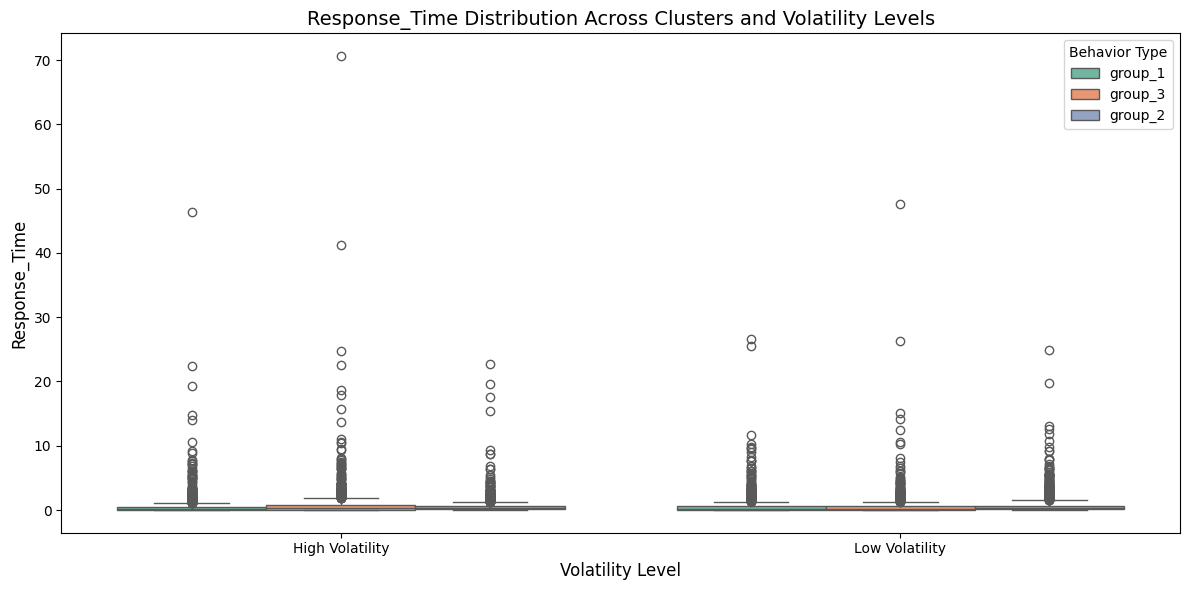


ANOVA Analysis Results for Volatility Effect:

                                              sum_sq      df         F  \
C(Behavior_Type)                           11.912983     2.0  1.620221   
C(Volatility_Numeric)                       1.588633     1.0  0.432123   
C(Behavior_Type):C(Volatility_Numeric)     55.817405     2.0  7.591426   
Residual                                27918.166153  7594.0       NaN   

                                          PR(>F)  
C(Behavior_Type)                        0.197923  
C(Volatility_Numeric)                   0.510969  
C(Behavior_Type):C(Volatility_Numeric)  0.000509  
Residual                                     NaN  

Difference in Performance Between Volatility Levels:

Volatility_Level  High Volatility  Low Volatility  Difference  Percent_Change
Behavior_Type                                                                
group_1                  0.617992        0.637992   -0.020000       -3.134834
group_2                  0.616142    

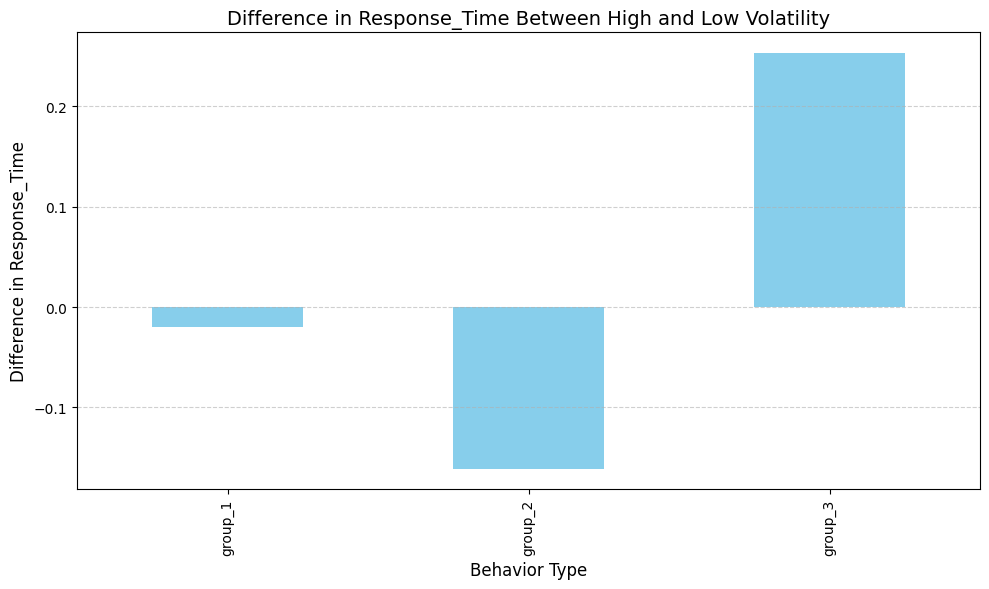



--- Volatility Analysis for Win-Stay ---


Descriptive Statistics by Cluster and Volatility Level:

                                 count      mean       std  min  25%  50%  \
Behavior_Type Volatility_Level                                              
group_1       High Volatility   1300.0  0.390769  0.488111  0.0  0.0  0.0   
              Low Volatility    1300.0  0.401538  0.490398  0.0  0.0  0.0   
group_2       High Volatility   1200.0  0.278333  0.448365  0.0  0.0  0.0   
              Low Volatility    1200.0  0.284167  0.451205  0.0  0.0  0.0   
group_3       High Volatility   1300.0  0.385385  0.486873  0.0  0.0  0.0   
              Low Volatility    1300.0  0.509231  0.500107  0.0  0.0  1.0   

                                75%  max  
Behavior_Type Volatility_Level            
group_1       High Volatility   1.0  1.0  
              Low Volatility    1.0  1.0  
group_2       High Volatility   1.0  1.0  
              Low Volatility    1.0  1.0  
group_3       High Vola

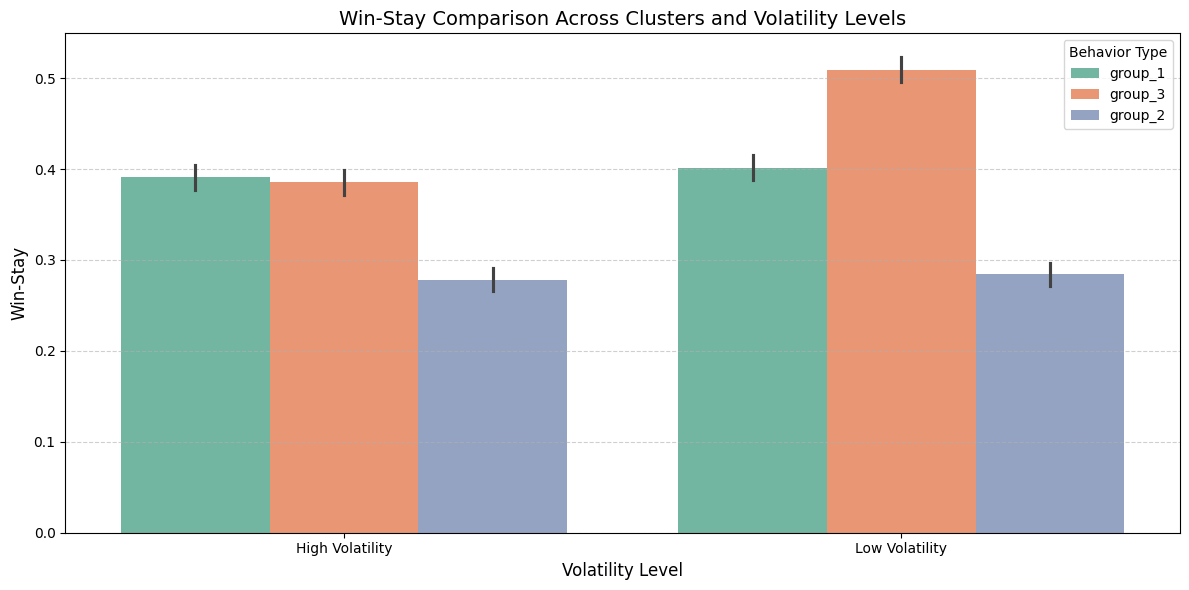

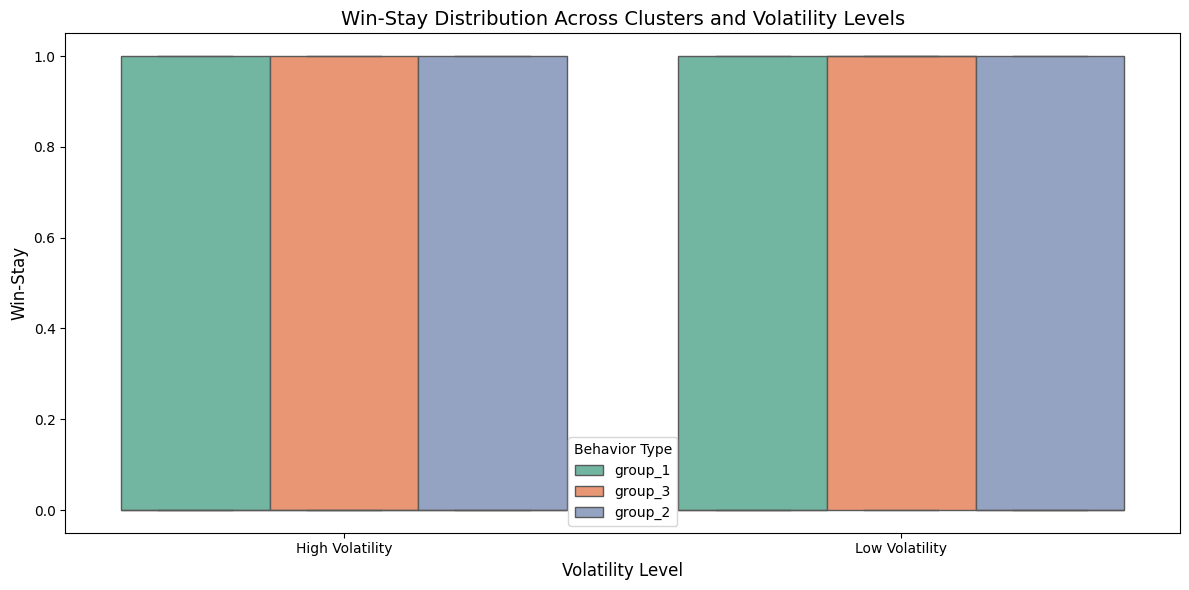

Error in ANOVA analysis for Win-Stay: error tokenizing input (maybe an unclosed string?)
    `Win-Stay` ~ C(Behavior_Type) * C(Volatility_Numeric)
    ^

Difference in Performance Between Volatility Levels:

Volatility_Level  High Volatility  Low Volatility  Difference  Percent_Change
Behavior_Type                                                                
group_1                  0.390769        0.401538   -0.010769       -2.681992
group_2                  0.278333        0.284167   -0.005833       -2.052786
group_3                  0.385385        0.509231   -0.123846      -24.320242


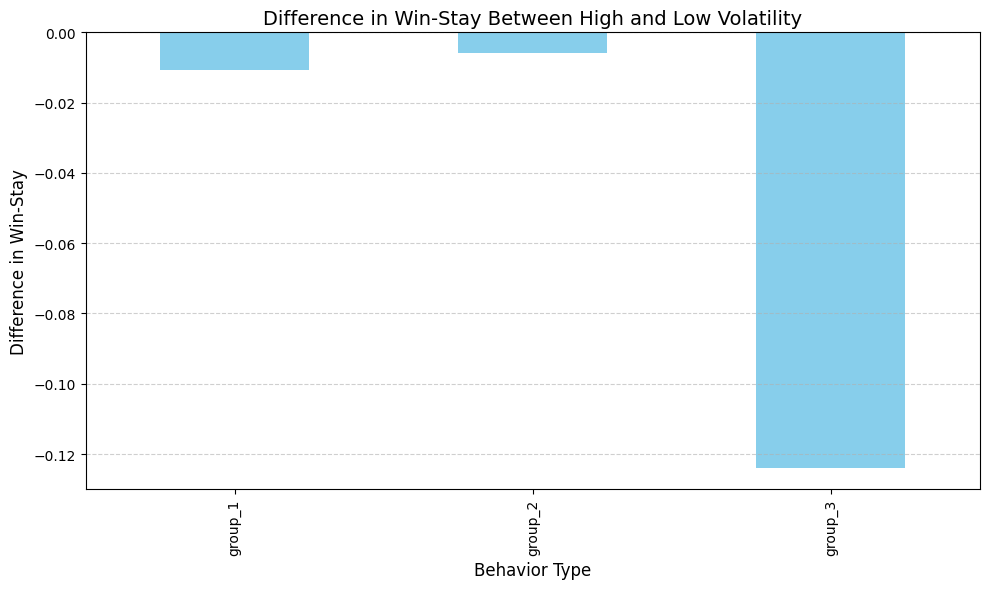



--- Volatility Analysis for Exploration ---


Descriptive Statistics by Cluster and Volatility Level:

                                 count      mean       std  min  25%  50%  \
Behavior_Type Volatility_Level                                              
group_1       High Volatility   1300.0  0.506154  0.500155  0.0  0.0  1.0   
              Low Volatility    1300.0  0.491538  0.500121  0.0  0.0  0.0   
group_2       High Volatility   1200.0  0.615000  0.486798  0.0  0.0  1.0   
              Low Volatility    1200.0  0.603333  0.489410  0.0  0.0  1.0   
group_3       High Volatility   1300.0  0.350000  0.477153  0.0  0.0  0.0   
              Low Volatility    1300.0  0.258462  0.437957  0.0  0.0  0.0   

                                75%  max  
Behavior_Type Volatility_Level            
group_1       High Volatility   1.0  1.0  
              Low Volatility    1.0  1.0  
group_2       High Volatility   1.0  1.0  
              Low Volatility    1.0  1.0  
group_3       High V

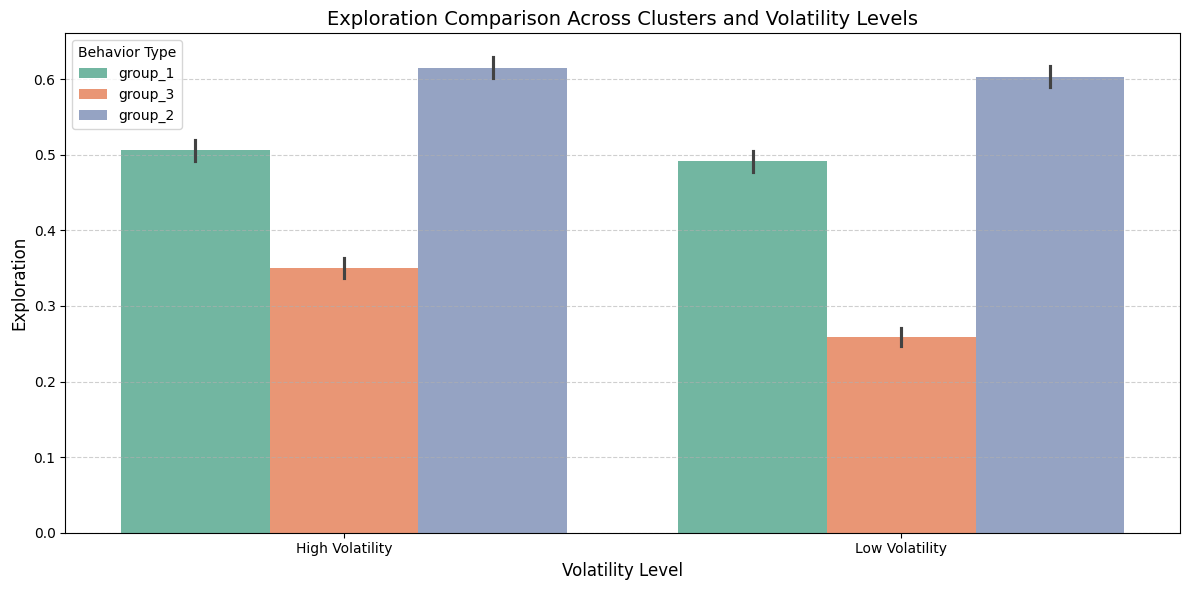

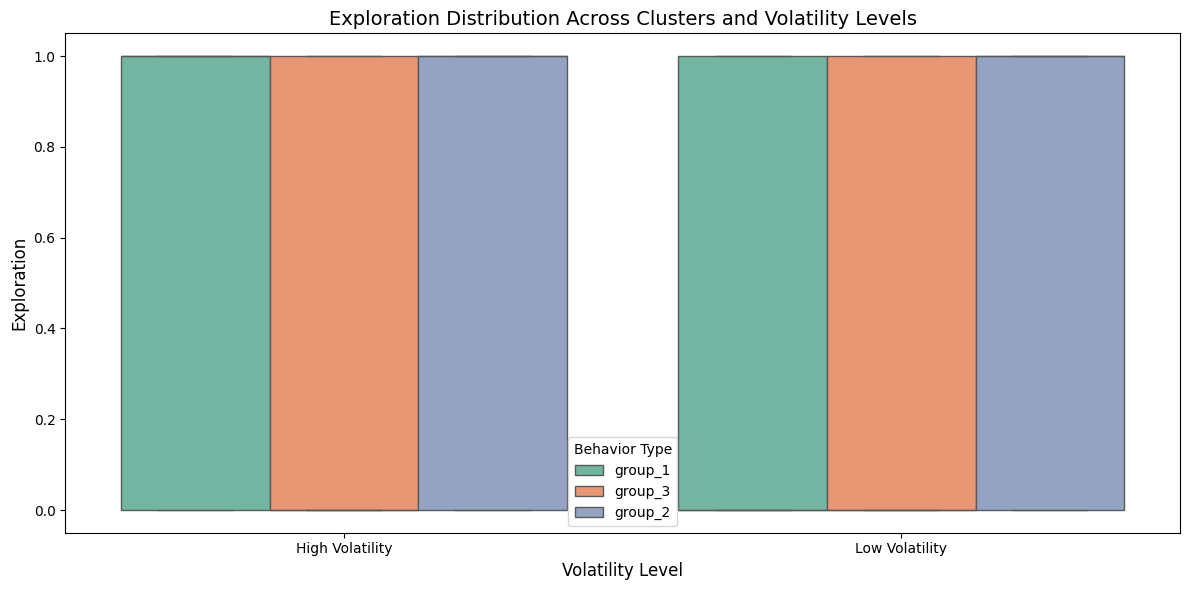


ANOVA Analysis Results for Volatility Effect:

                                             sum_sq      df           F  \
C(Behavior_Type)                         120.027982     2.0  258.055082   
C(Volatility_Numeric)                      3.040000     1.0   13.071743   
C(Behavior_Type):C(Volatility_Numeric)     2.627051     2.0    5.648049   
Residual                                1766.081282  7594.0         NaN   

                                               PR(>F)  
C(Behavior_Type)                        3.734719e-109  
C(Volatility_Numeric)                    3.017266e-04  
C(Behavior_Type):C(Volatility_Numeric)   3.539207e-03  
Residual                                          NaN  

Difference in Performance Between Volatility Levels:

Volatility_Level  High Volatility  Low Volatility  Difference  Percent_Change
Behavior_Type                                                                
group_1                  0.506154        0.491538    0.014615        2.973396
group_2

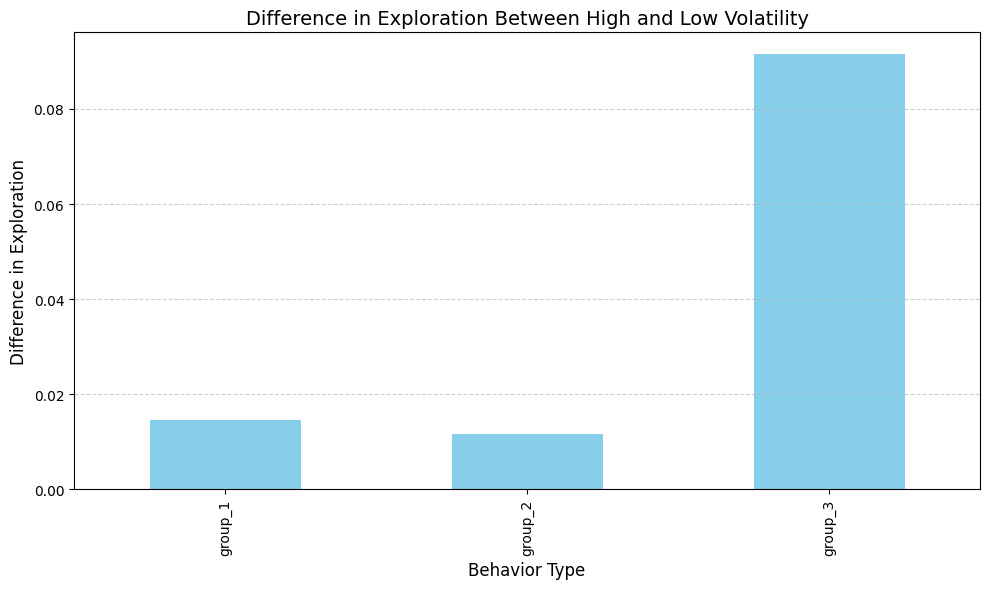



--- Volatility Analysis for Exploitation ---


Descriptive Statistics by Cluster and Volatility Level:

                                 count      mean       std  min  25%  50%  \
Behavior_Type Volatility_Level                                              
group_1       High Volatility   1300.0  0.489231  0.500076  0.0  0.0  0.0   
              Low Volatility    1300.0  0.503077  0.500183  0.0  0.0  1.0   
group_2       High Volatility   1200.0  0.381667  0.485998  0.0  0.0  0.0   
              Low Volatility    1200.0  0.390000  0.487953  0.0  0.0  0.0   
group_3       High Volatility   1300.0  0.643077  0.479276  0.0  0.0  1.0   
              Low Volatility    1300.0  0.738462  0.439642  0.0  0.0  1.0   

                                75%  max  
Behavior_Type Volatility_Level            
group_1       High Volatility   1.0  1.0  
              Low Volatility    1.0  1.0  
group_2       High Volatility   1.0  1.0  
              Low Volatility    1.0  1.0  
group_3       High 

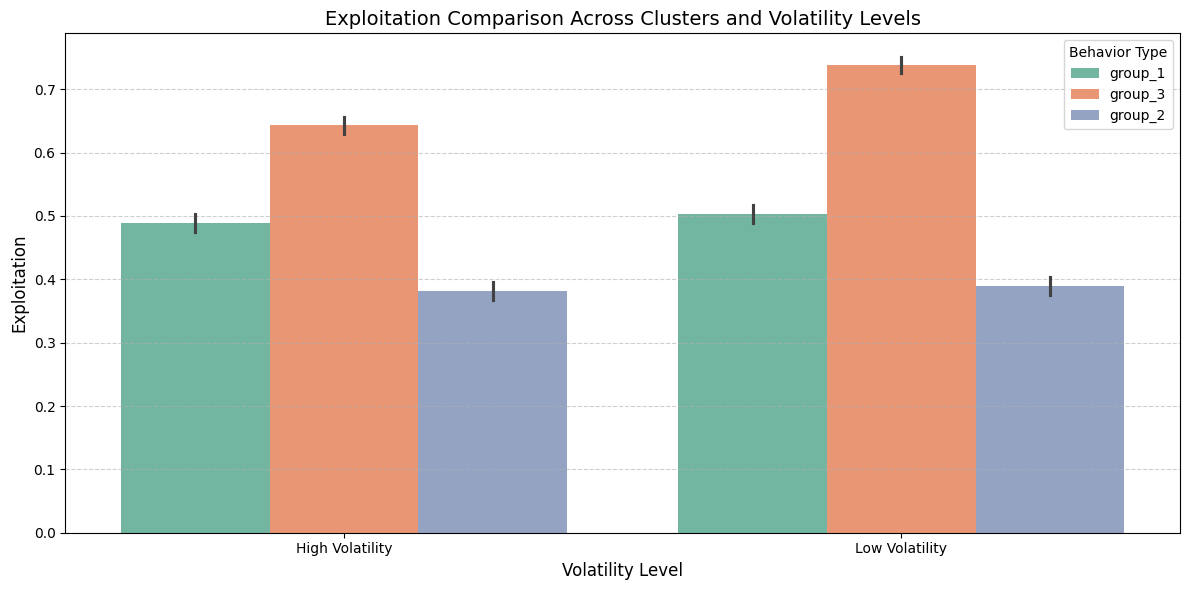

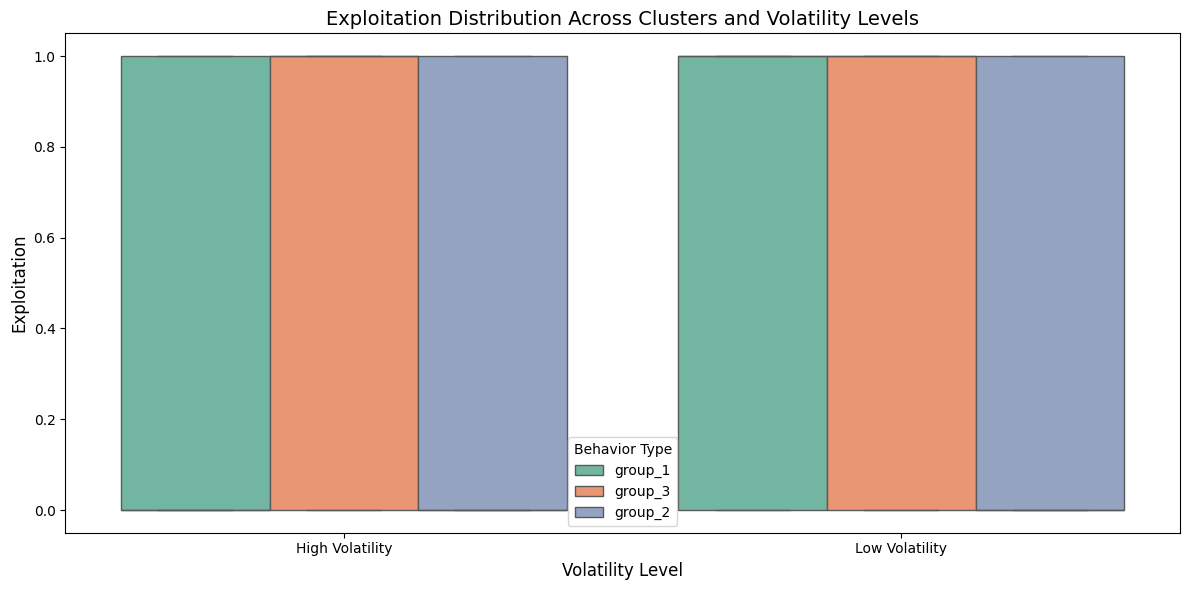


ANOVA Analysis Results for Volatility Effect:

                                             sum_sq      df           F  \
C(Behavior_Type)                         120.027982     2.0  257.778206   
C(Volatility_Numeric)                      3.040000     1.0   13.057718   
C(Behavior_Type):C(Volatility_Numeric)     3.040128     2.0    6.529134   
Residual                                1767.978205  7594.0         NaN   

                                               PR(>F)  
C(Behavior_Type)                        4.840111e-109  
C(Volatility_Numeric)                    3.039904e-04  
C(Behavior_Type):C(Volatility_Numeric)   1.468481e-03  
Residual                                          NaN  

Difference in Performance Between Volatility Levels:

Volatility_Level  High Volatility  Low Volatility  Difference  Percent_Change
Behavior_Type                                                                
group_1                  0.489231        0.503077   -0.013846       -2.752294
group_2

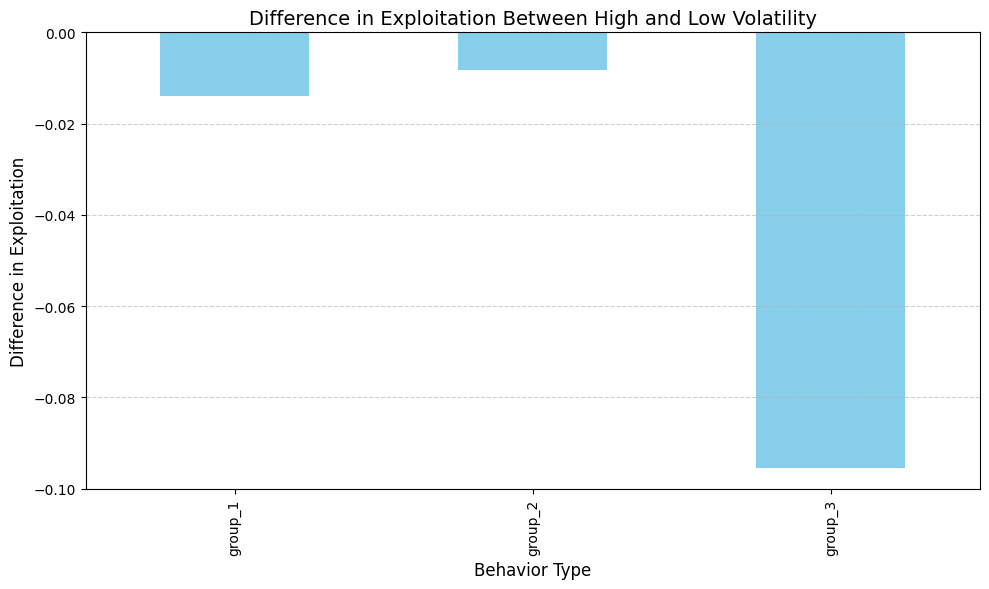

In [17]:
# Main function to run the entire pipeline
def main():
    # Load and preprocess data
    file_path = "/content/Complete game data csv(modified envo)38participents.csv"  # Update this path as needed
    print(f"Loading data from {file_path}")
    df = load_and_preprocess_data(file_path)

    # Define features
    time_features = ["Reward", "Score", "Win-Stay", "Lose-Shift",
                    "Exploration", "Exploitation", "Response_Time"]

    features_to_use = [
        "Environment", "Environment_Type", "Chosen_Island", "Probability",
        "Random_Value", "Reward", "Score", "Response_Time", "Lose-Shift",
        "Exploration", "Exploitation", "Win-Stay"
    ]

    #Data Visualisation
    explore_dataset(df)

    # Normalize features
    df_norm = normalize_features(df, features_to_use)

    # Create sequences
    sequence_array, participant_ids = create_sequences(df_norm, features_to_use)

    # Create TensorFlow dataset
    dataset = create_tf_dataset(sequence_array)

    # Build model
    timesteps = sequence_array.shape[1]
    n_features = sequence_array.shape[2]
    autoencoder, encoder = build_lstm_autoencoder(timesteps, n_features)

    # Summarize model architecture
    autoencoder.summary()

    # Train autoencoder
    trained_autoencoder = train_autoencoder(autoencoder, dataset)

    # Generate embeddings
    embeddings = encoder.predict(sequence_array)
    print("Generated embeddings with shape:", embeddings.shape)

    # Dimensionality reduction (both t-SNE and UMAP)
    reduced_embeddings = perform_dimensionality_reduction(embeddings)

    # Clustering
    clustering_results = perform_clustering(reduced_embeddings)

    # Visualize clusters
    for method, embeddings_2d in reduced_embeddings.items():
        visualize_clusters(embeddings_2d, clustering_results[method],
                          participant_ids, method)

    # Analyze clusters (using t-SNE results for analysis)
    df_labeled = analyze_clusters(df, participant_ids,
                                 clustering_results['tsne'], time_features)

    # # Assuming df is already created and has relevant columns
    # performance_summary, anova_results = analyze_cluster_performance_by_environment(df_labeled)
    # # Print the performance summary and ANOVA results
    # print(" Performance Summary:")
    # print(performance_summary)

    # print("\n ANOVA Results:")
    # print(anova_results)

    # print("Analysis complete!")
    # Analyze performance by environment
    print("\n--- Analyzing Performance by Environment Type ---")
    performance_metrics = ["Score", "Reward", "Response_Time", "Win-Stay", "Exploration", "Exploitation"]
    performance_summary, anova_results = analyze_cluster_performance_by_environment(df_labeled, performance_metrics=performance_metrics)

    # Analyze performance by volatility level
    print("\n--- Analyzing Performance by Volatility Level ---")
    volatility_summary, volatility_anova, df_with_volatility = analyze_performance_by_volatility(
        df_labeled,
        performance_metrics=["Score", "Reward", "Response_Time", "Win-Stay", "Exploration", "Exploitation"])


    return df_labeled



if __name__ == "__main__":
    df_labeled = main()